# AI for Healthcare - Week 3 & 4 Assignment

## Project Title
Chest X-ray Object Detection using YOLOv8 Oriented Bounding Box (OBB)

### Objective
The aim of this project is to train a YOLOv8 model on a chest X-ray dataset and detect the object using Oriented Bounding Boxes (OBB).

In [12]:
# Installing required libraries
!pip install ultralytics
!pip install roboflow

In [13]:
# Import YOLO model
from ultralytics import YOLO

# Import Roboflow to download dataset
from roboflow import Roboflow

# Import os module for working with files
import os

In [14]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="XprIetE05kQWU8MWtzFC")
project = rf.workspace("saharsh-kumar-singh").project("ge-healthcare-hackathon-qaitt")
version = project.version(1)
dataset = version.download("yolov8-obb")


loading Roboflow workspace...
loading Roboflow project...


In [15]:
# Load pretrained YOLOv8 OBB model
model = YOLO("yolov8n-obb.pt")

In [16]:
# Train the YOLO model
model = YOLO("yolov8n-obb.pt")

results = model.train(
    data="/content/GE-healthcare-hackathon-1/data.yaml",
    epochs=20,
    imgsz=640,
    batch=8
)

Ultralytics 8.4.77 🚀 Python-3.12.13 torch-2.11.0+cpu CPU (AMD EPYC 7B12)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/GE-healthcare-hackathon-1/data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n-obb.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train-2, nbs=64, nms=False, opset=None, optimize=False, optimizer=

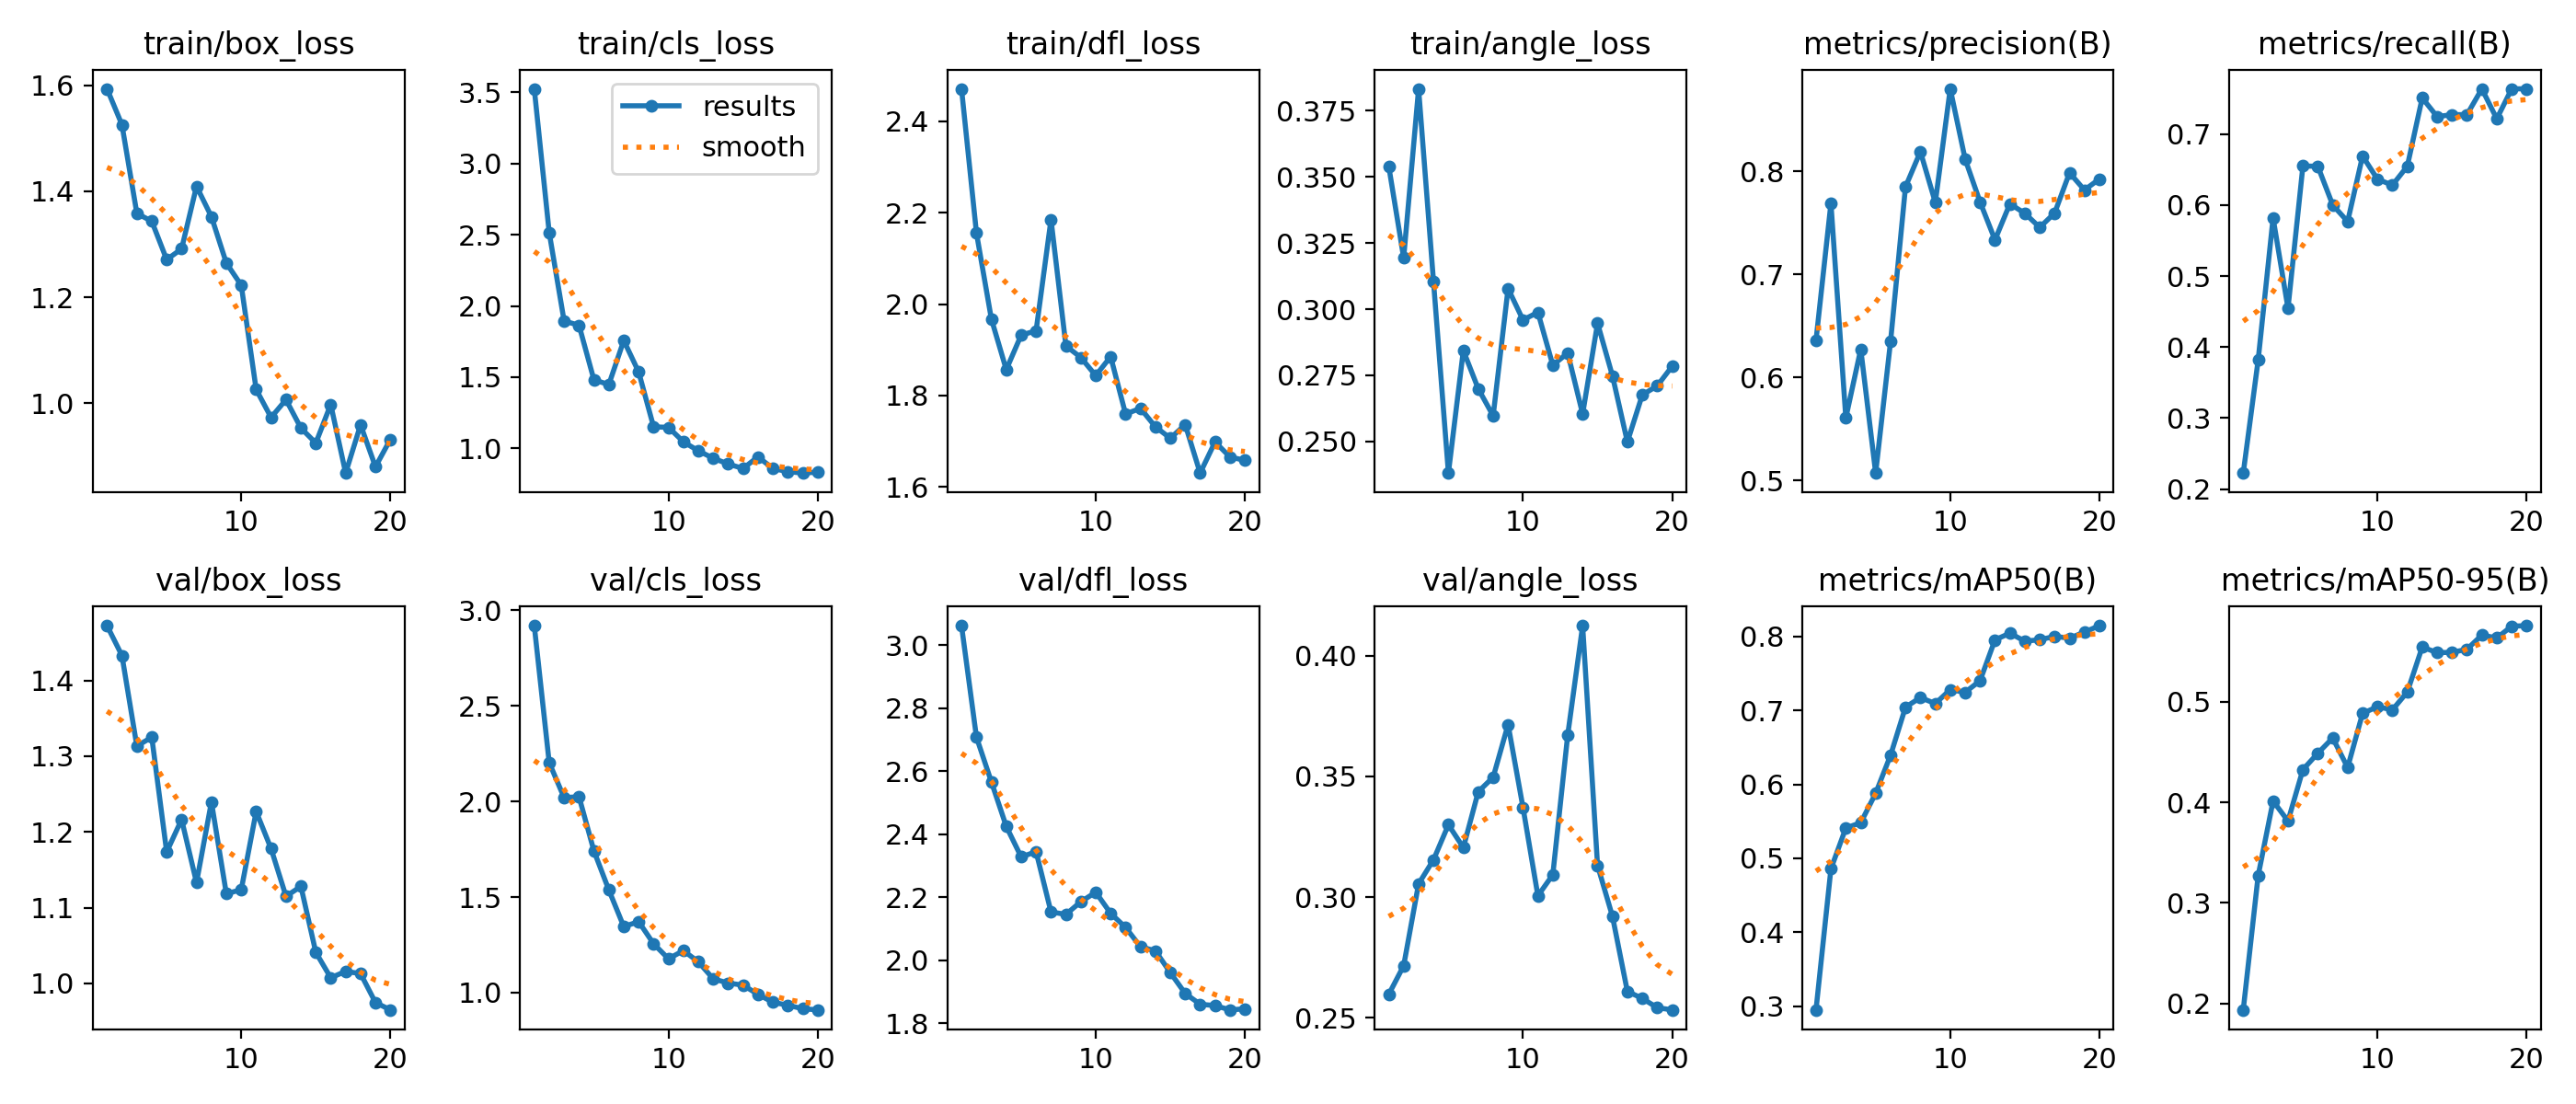

In [17]:
from IPython.display import Image, display

# Display training graphs
display(Image("/content/runs/obb/train/results.png", width=900))

In [18]:
# Load the trained model
model = YOLO("/content/runs/obb/train/weights/best.pt")

# Run prediction
model.predict(
    source="/content/GE-healthcare-hackathon-1/test/images",
    save=True,
    conf=0.25
)


image 1/12 /content/GE-healthcare-hackathon-1/test/images/00000013_015_png.rf.7b1f701b2fdfc13ca722a7cbae652a9d.jpg: 640x640 2 objects, 151.7ms
image 2/12 /content/GE-healthcare-hackathon-1/test/images/00000013_034_png.rf.249ab1d40b2d1840b6652aaaf3c4e244.jpg: 640x640 2 objects, 158.7ms
image 3/12 /content/GE-healthcare-hackathon-1/test/images/00000038_003_png.rf.625047342dd87e2607a0637ee97cbf9e.jpg: 640x640 2 objects, 146.9ms
image 4/12 /content/GE-healthcare-hackathon-1/test/images/00000038_007_png.rf.372274b29b6fdbb17be5ab6e5be23f3d.jpg: 640x640 2 objects, 213.6ms
image 5/12 /content/GE-healthcare-hackathon-1/test/images/00000061_002_png.rf.b63ef1b24f4858bff24174677ef07664.jpg: 640x640 5 objects, 266.5ms
image 6/12 /content/GE-healthcare-hackathon-1/test/images/00000061_009_png.rf.5c4e5903591f897e4377879804269467.jpg: 640x640 4 objects, 353.1ms
image 7/12 /content/GE-healthcare-hackathon-1/test/images/00000061_016_png.rf.9f73f25332ac9daaab7ff158489e3666.jpg: 640x640 3 objects, 275.6m

[ultralytics.engine.results.Results object with attributes:
 
 boxes: None
 keypoints: None
 masks: None
 names: {0: 'object'}
 obb: ultralytics.engine.results.OBB object
 orig_img: array([[[ 61,  61,  61],
         [ 57,  57,  57],
         [ 52,  52,  52],
         ...,
         [144, 144, 144],
         [142, 142, 142],
         [141, 141, 141]],
 
        [[ 66,  66,  66],
         [ 63,  63,  63],
         [ 57,  57,  57],
         ...,
         [139, 139, 139],
         [139, 139, 139],
         [138, 138, 138]],
 
        [[ 74,  74,  74],
         [ 70,  70,  70],
         [ 64,  64,  64],
         ...,
         [140, 140, 140],
         [142, 142, 142],
         [142, 142, 142]],
 
        ...,
 
        [[ 18,  18,  18],
         [ 18,  18,  18],
         [ 29,  29,  29],
         ...,
         [116, 116, 116],
         [115, 115, 115],
         [115, 115, 115]],
 
        [[ 21,  21,  21],
         [ 22,  22,  22],
         [ 34,  34,  34],
         ...,
         [116, 116, 

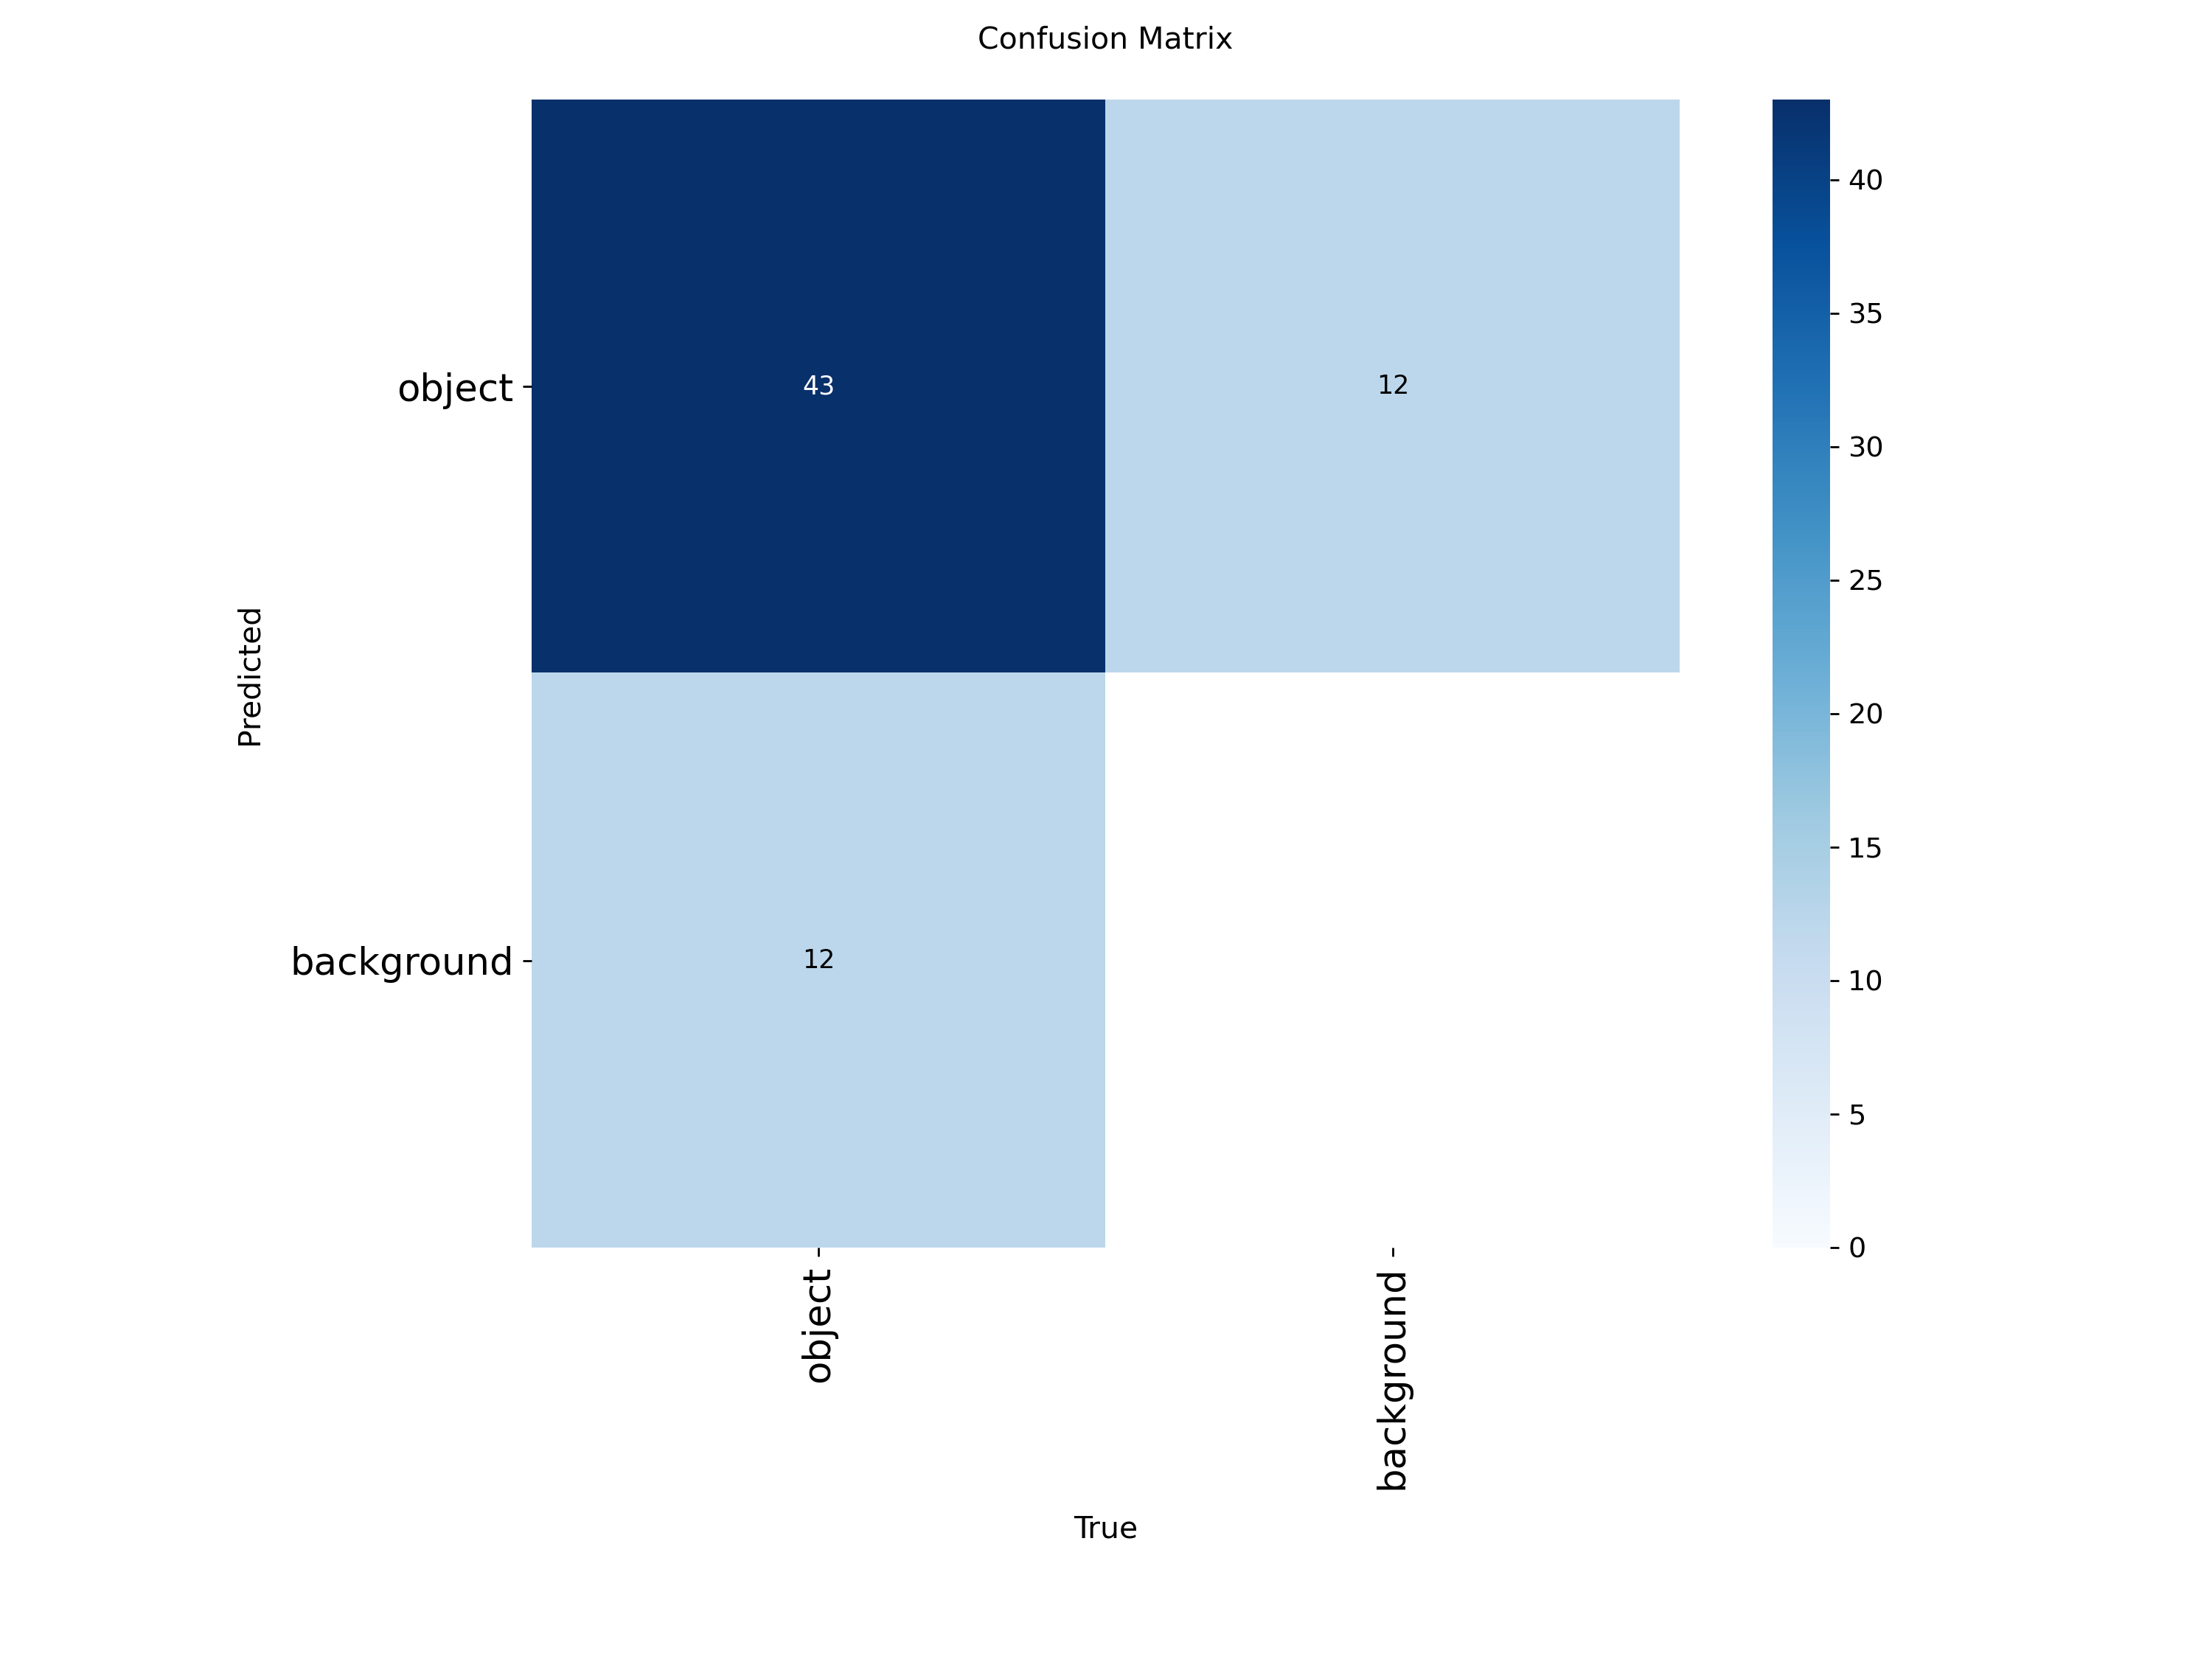

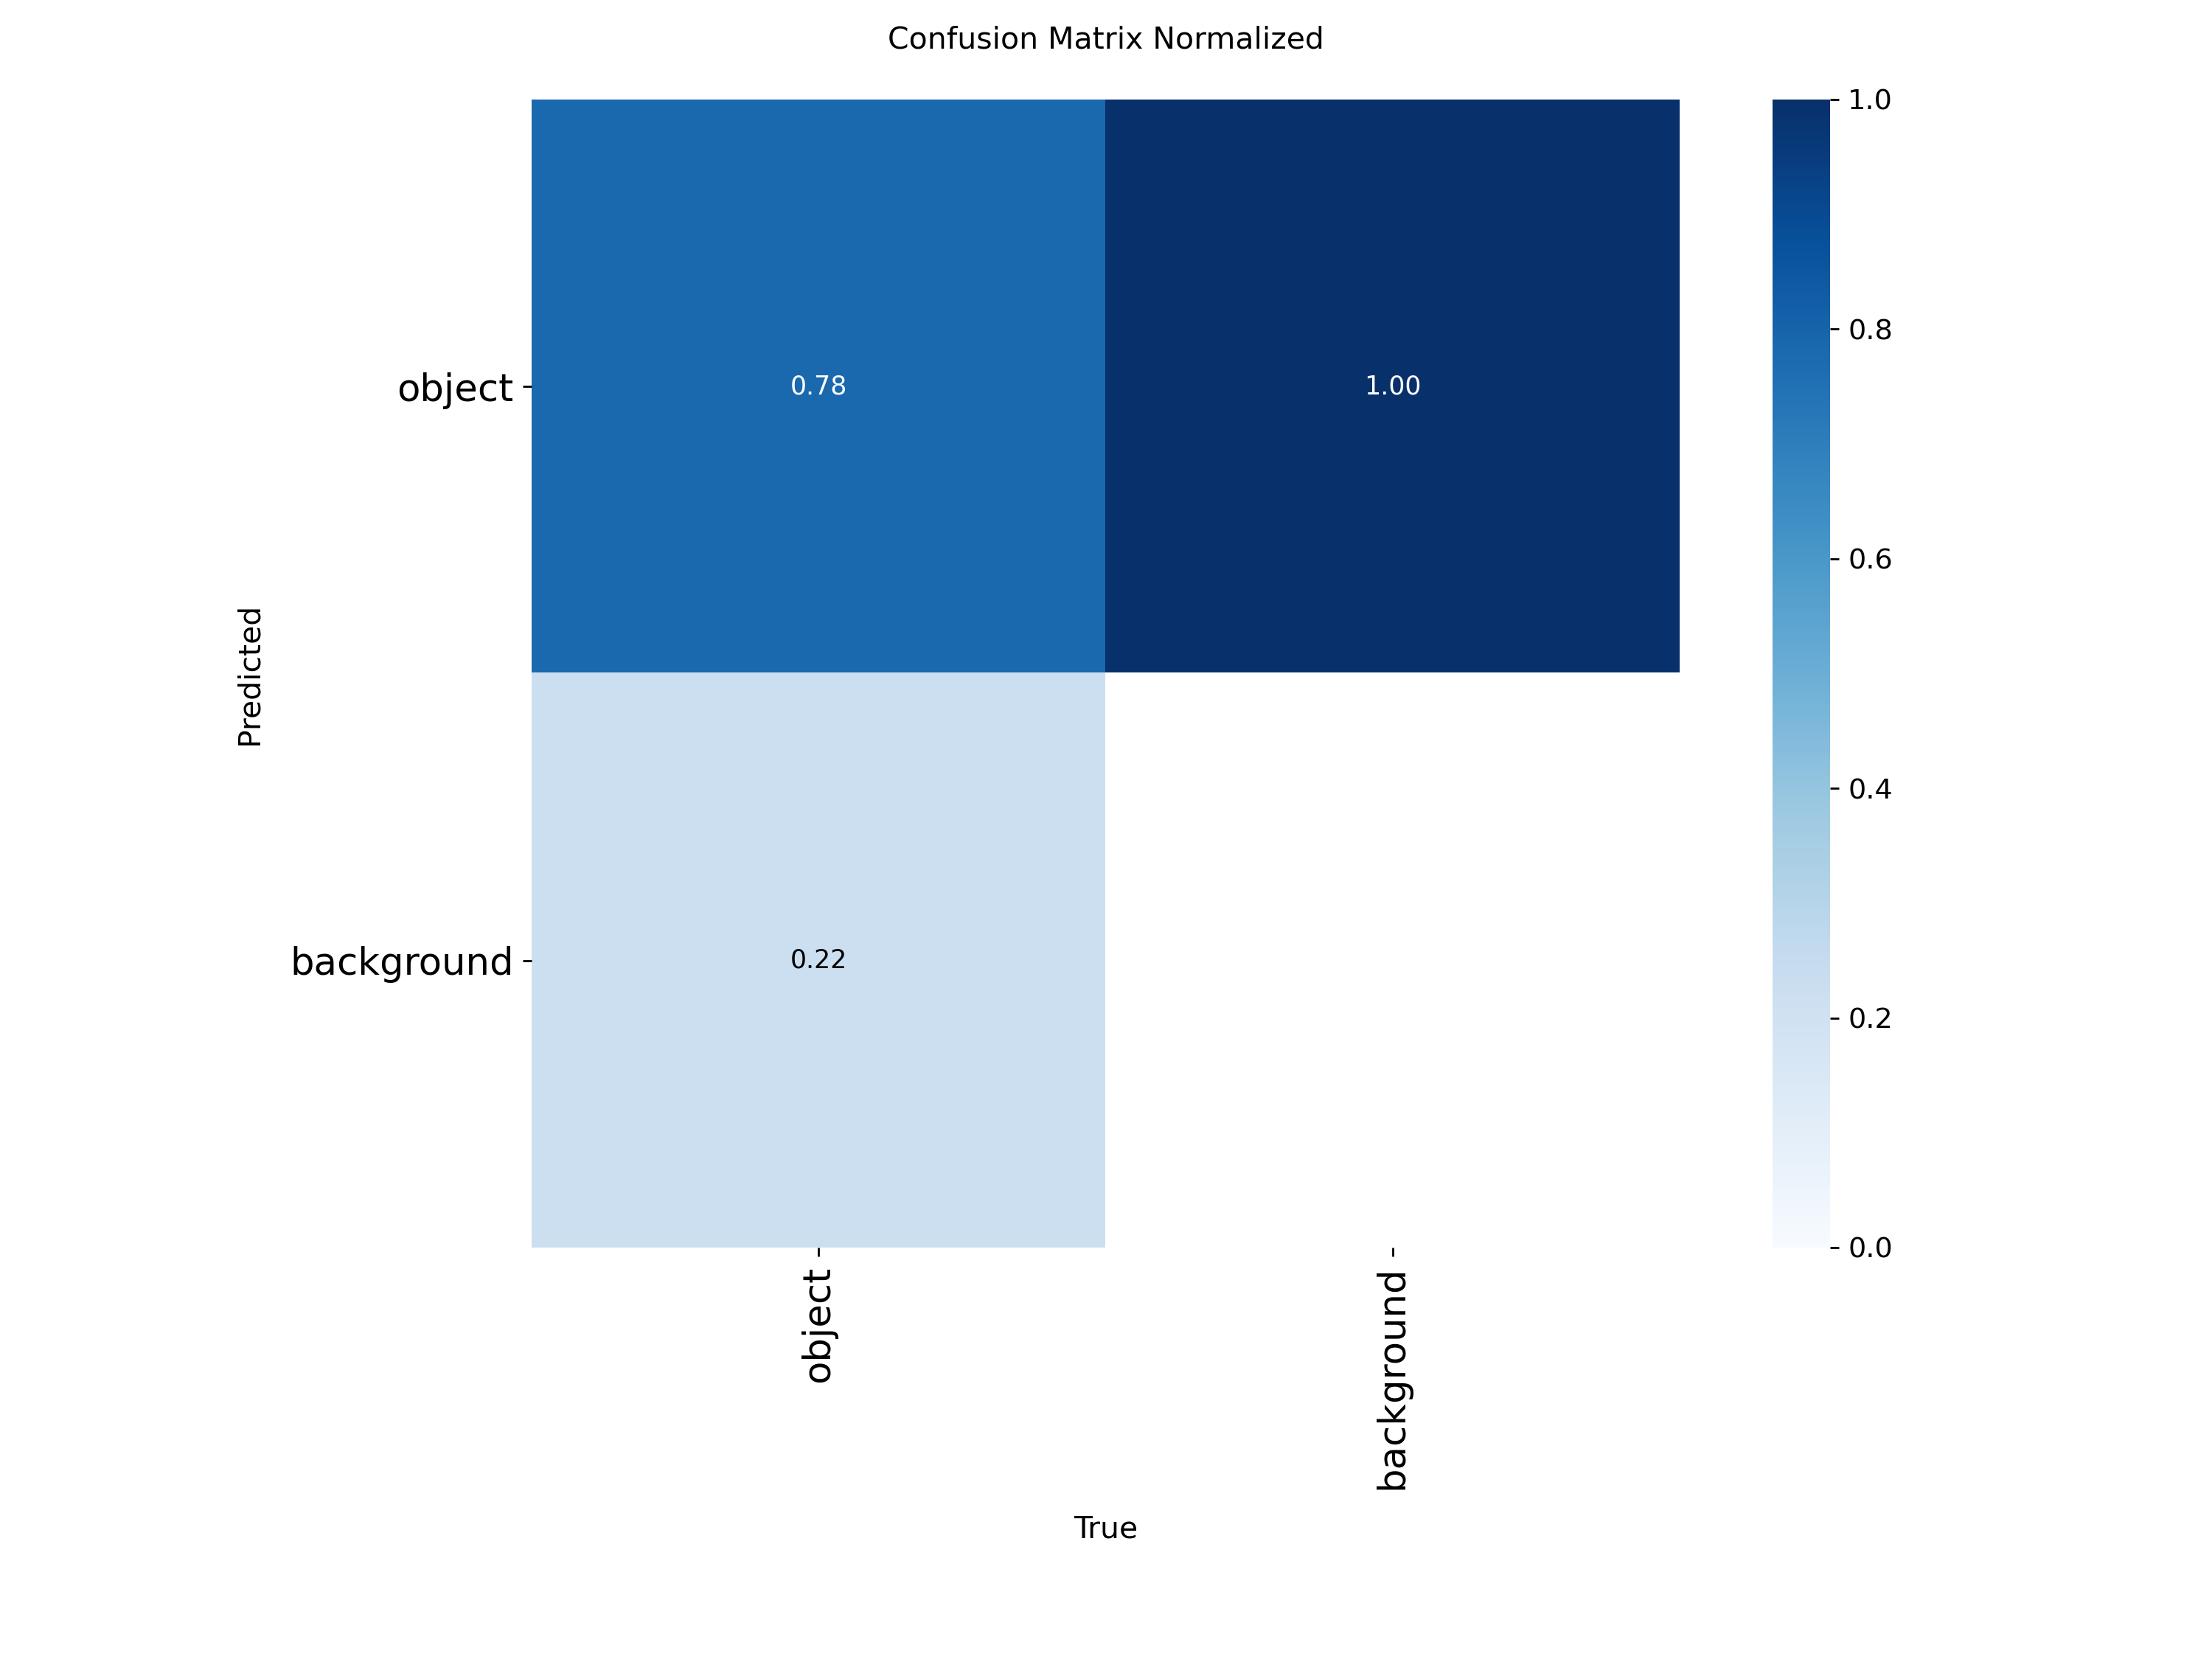

In [19]:
# Confusion Matrix
display(Image("/content/runs/obb/train/confusion_matrix.png", width=600))
display(Image("/content/runs/obb/train/confusion_matrix_normalized.png", width=600))

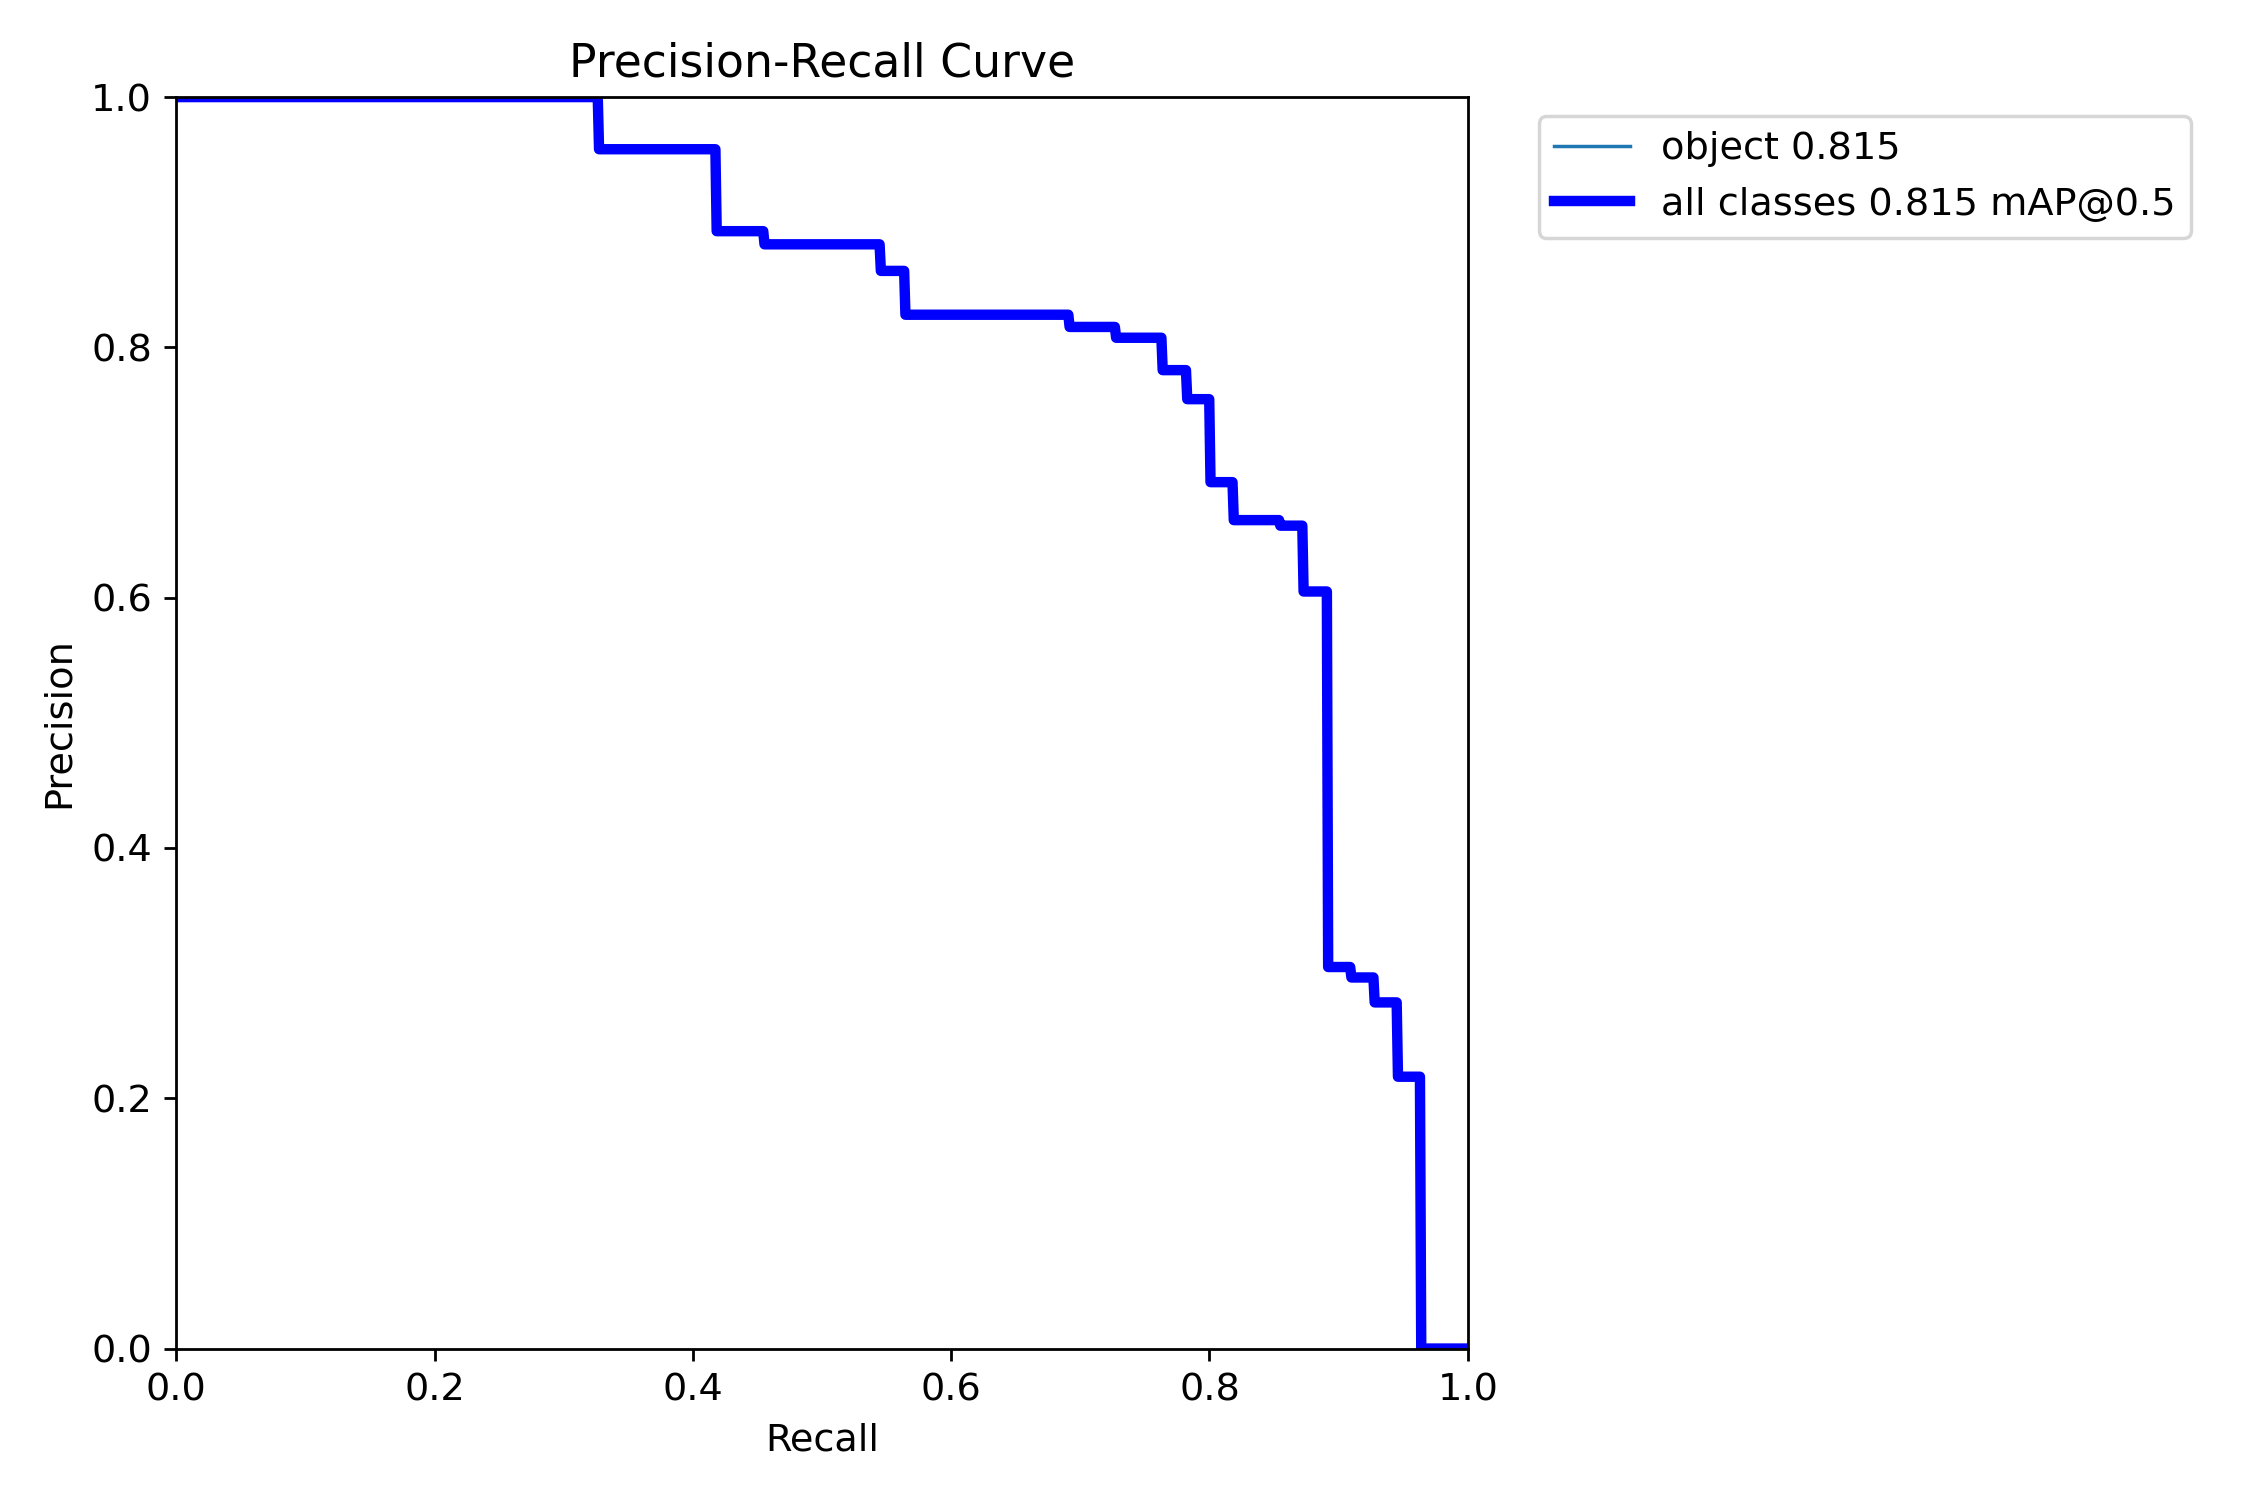

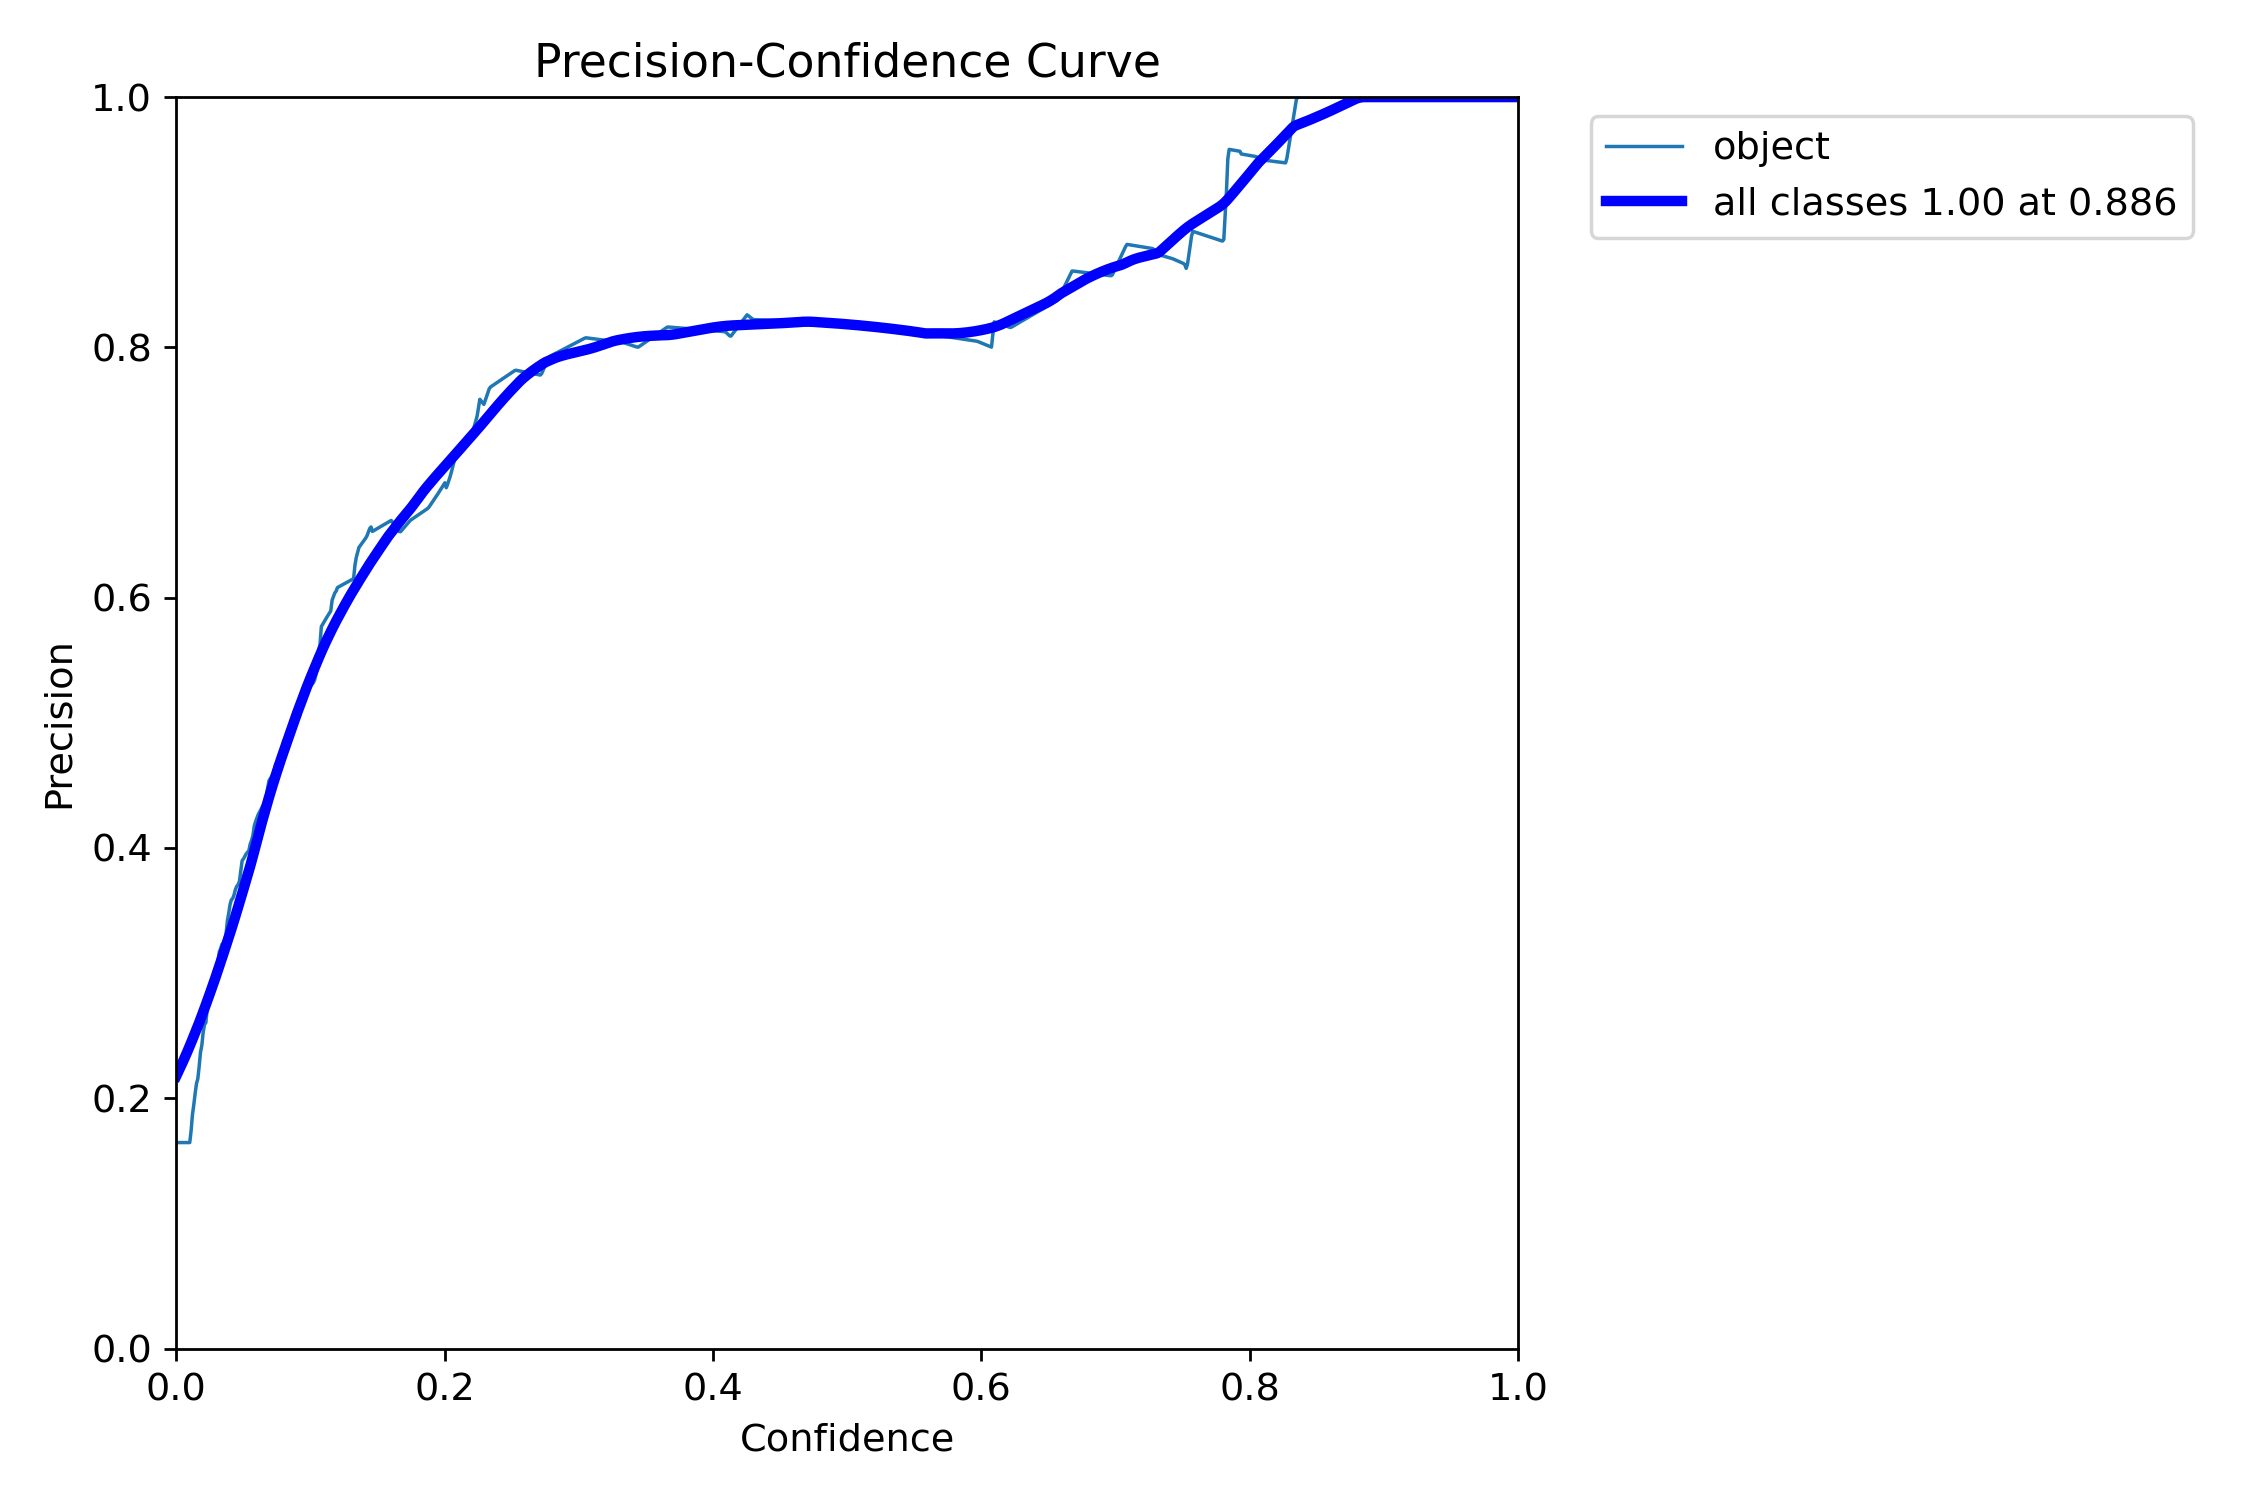

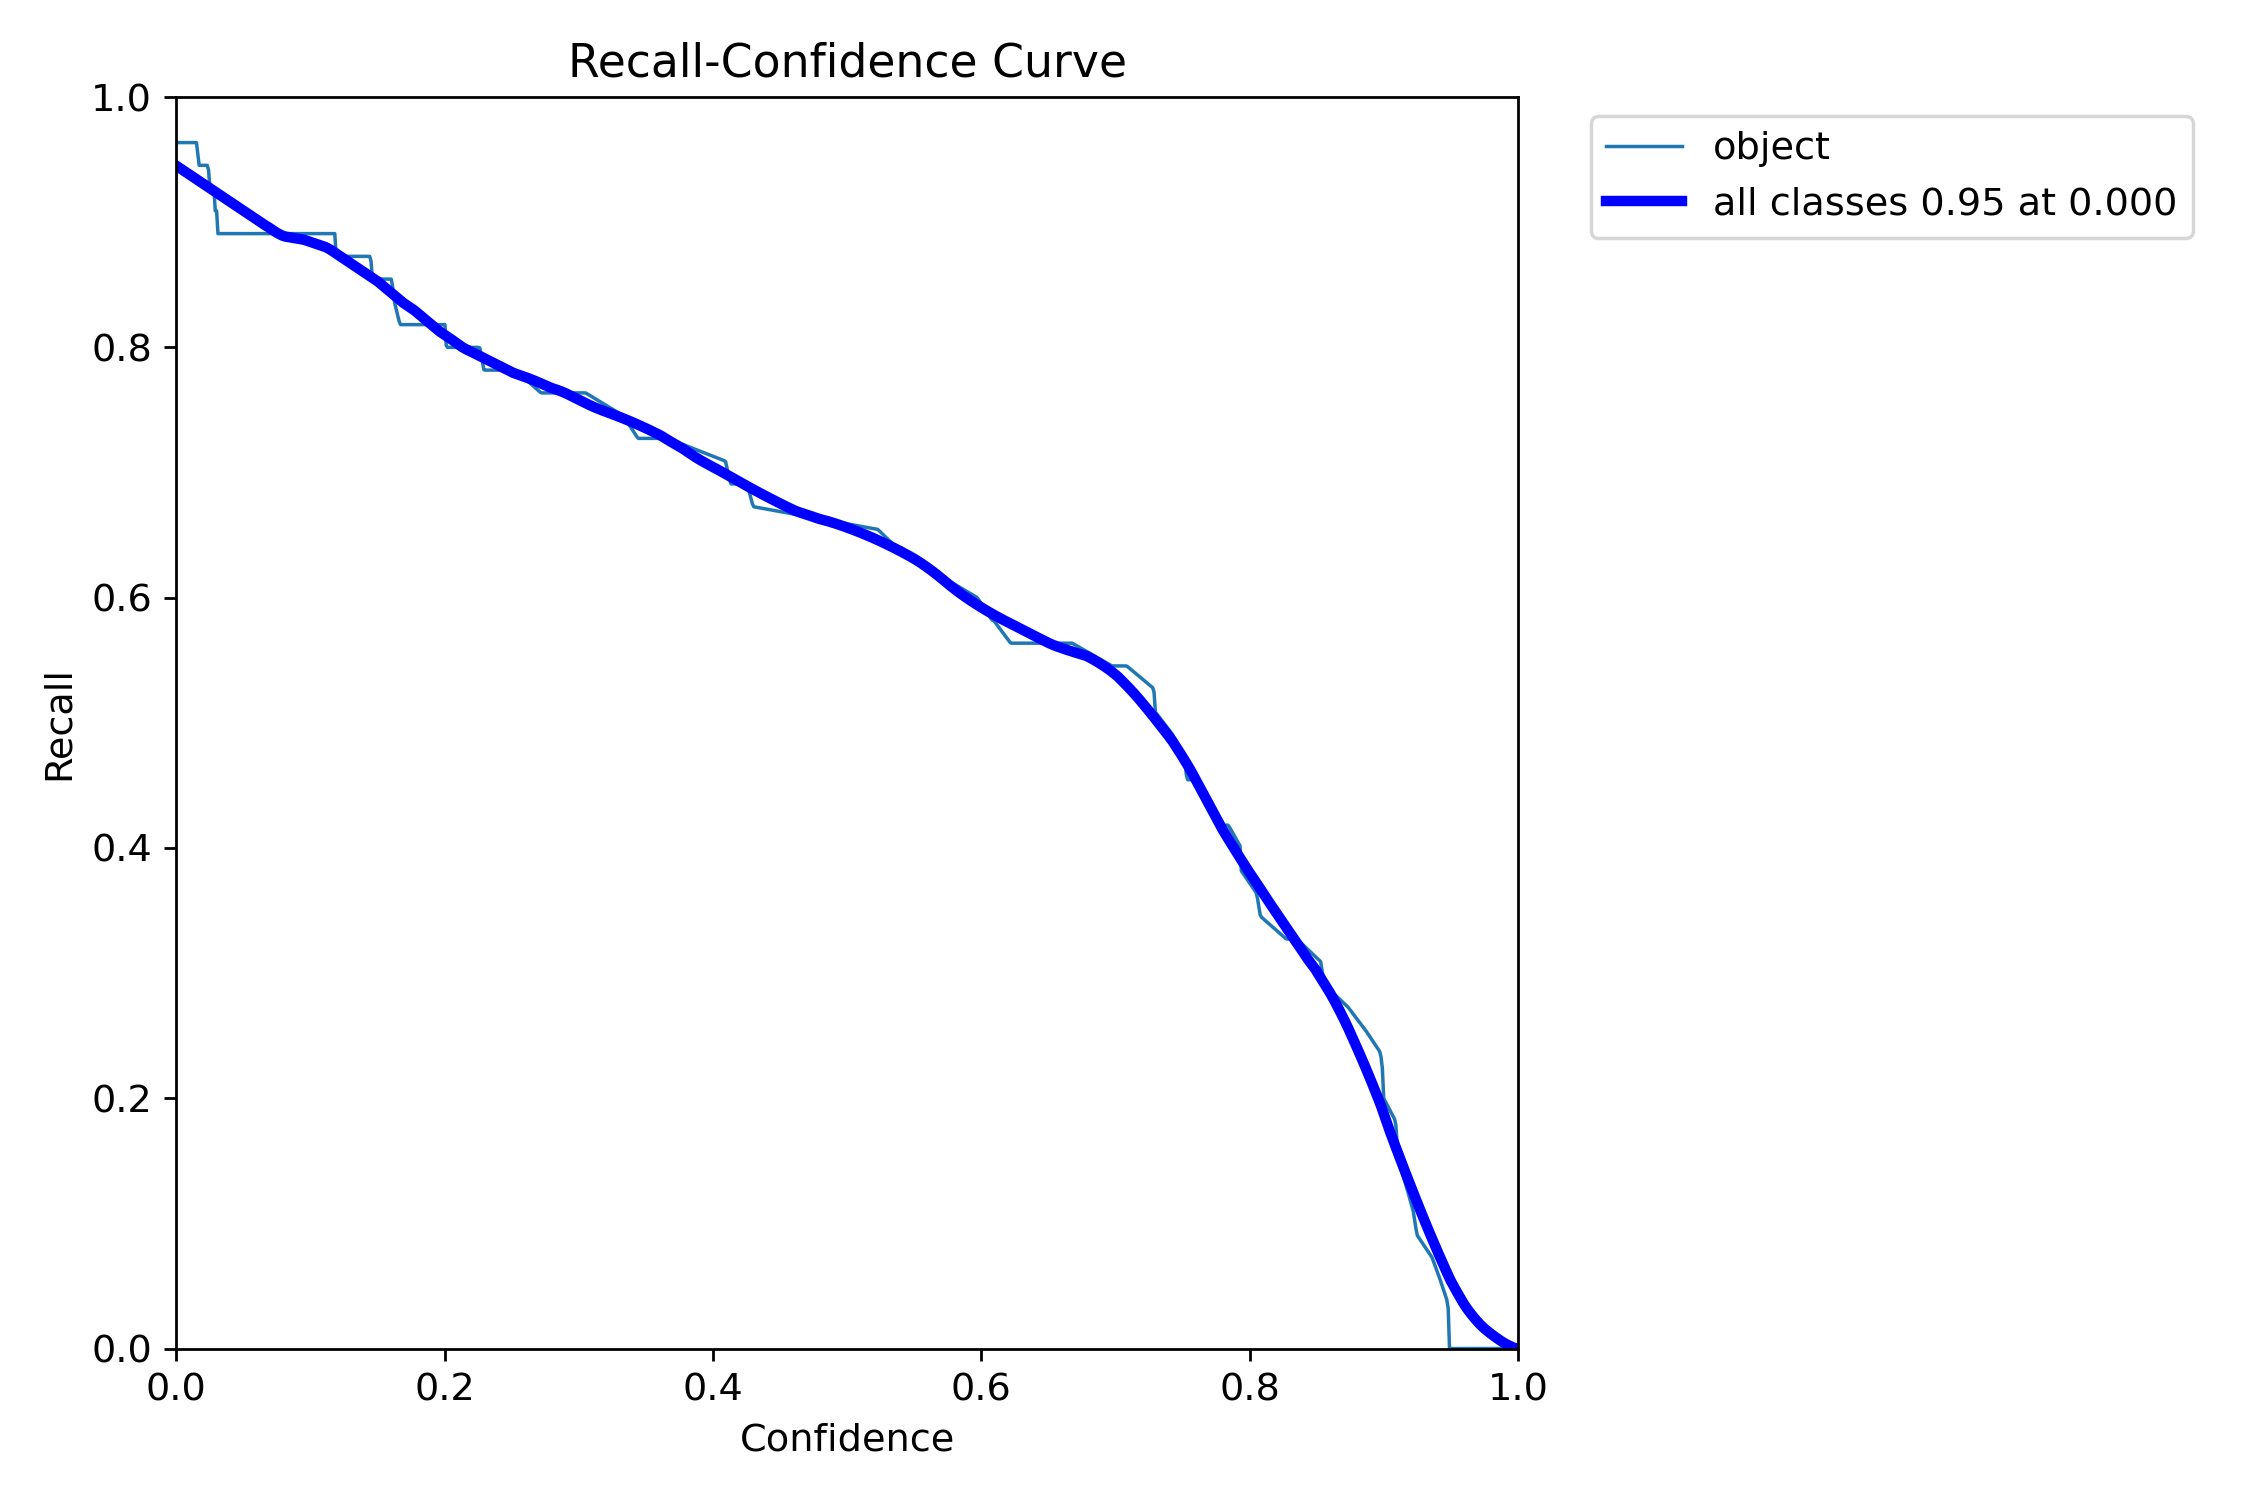

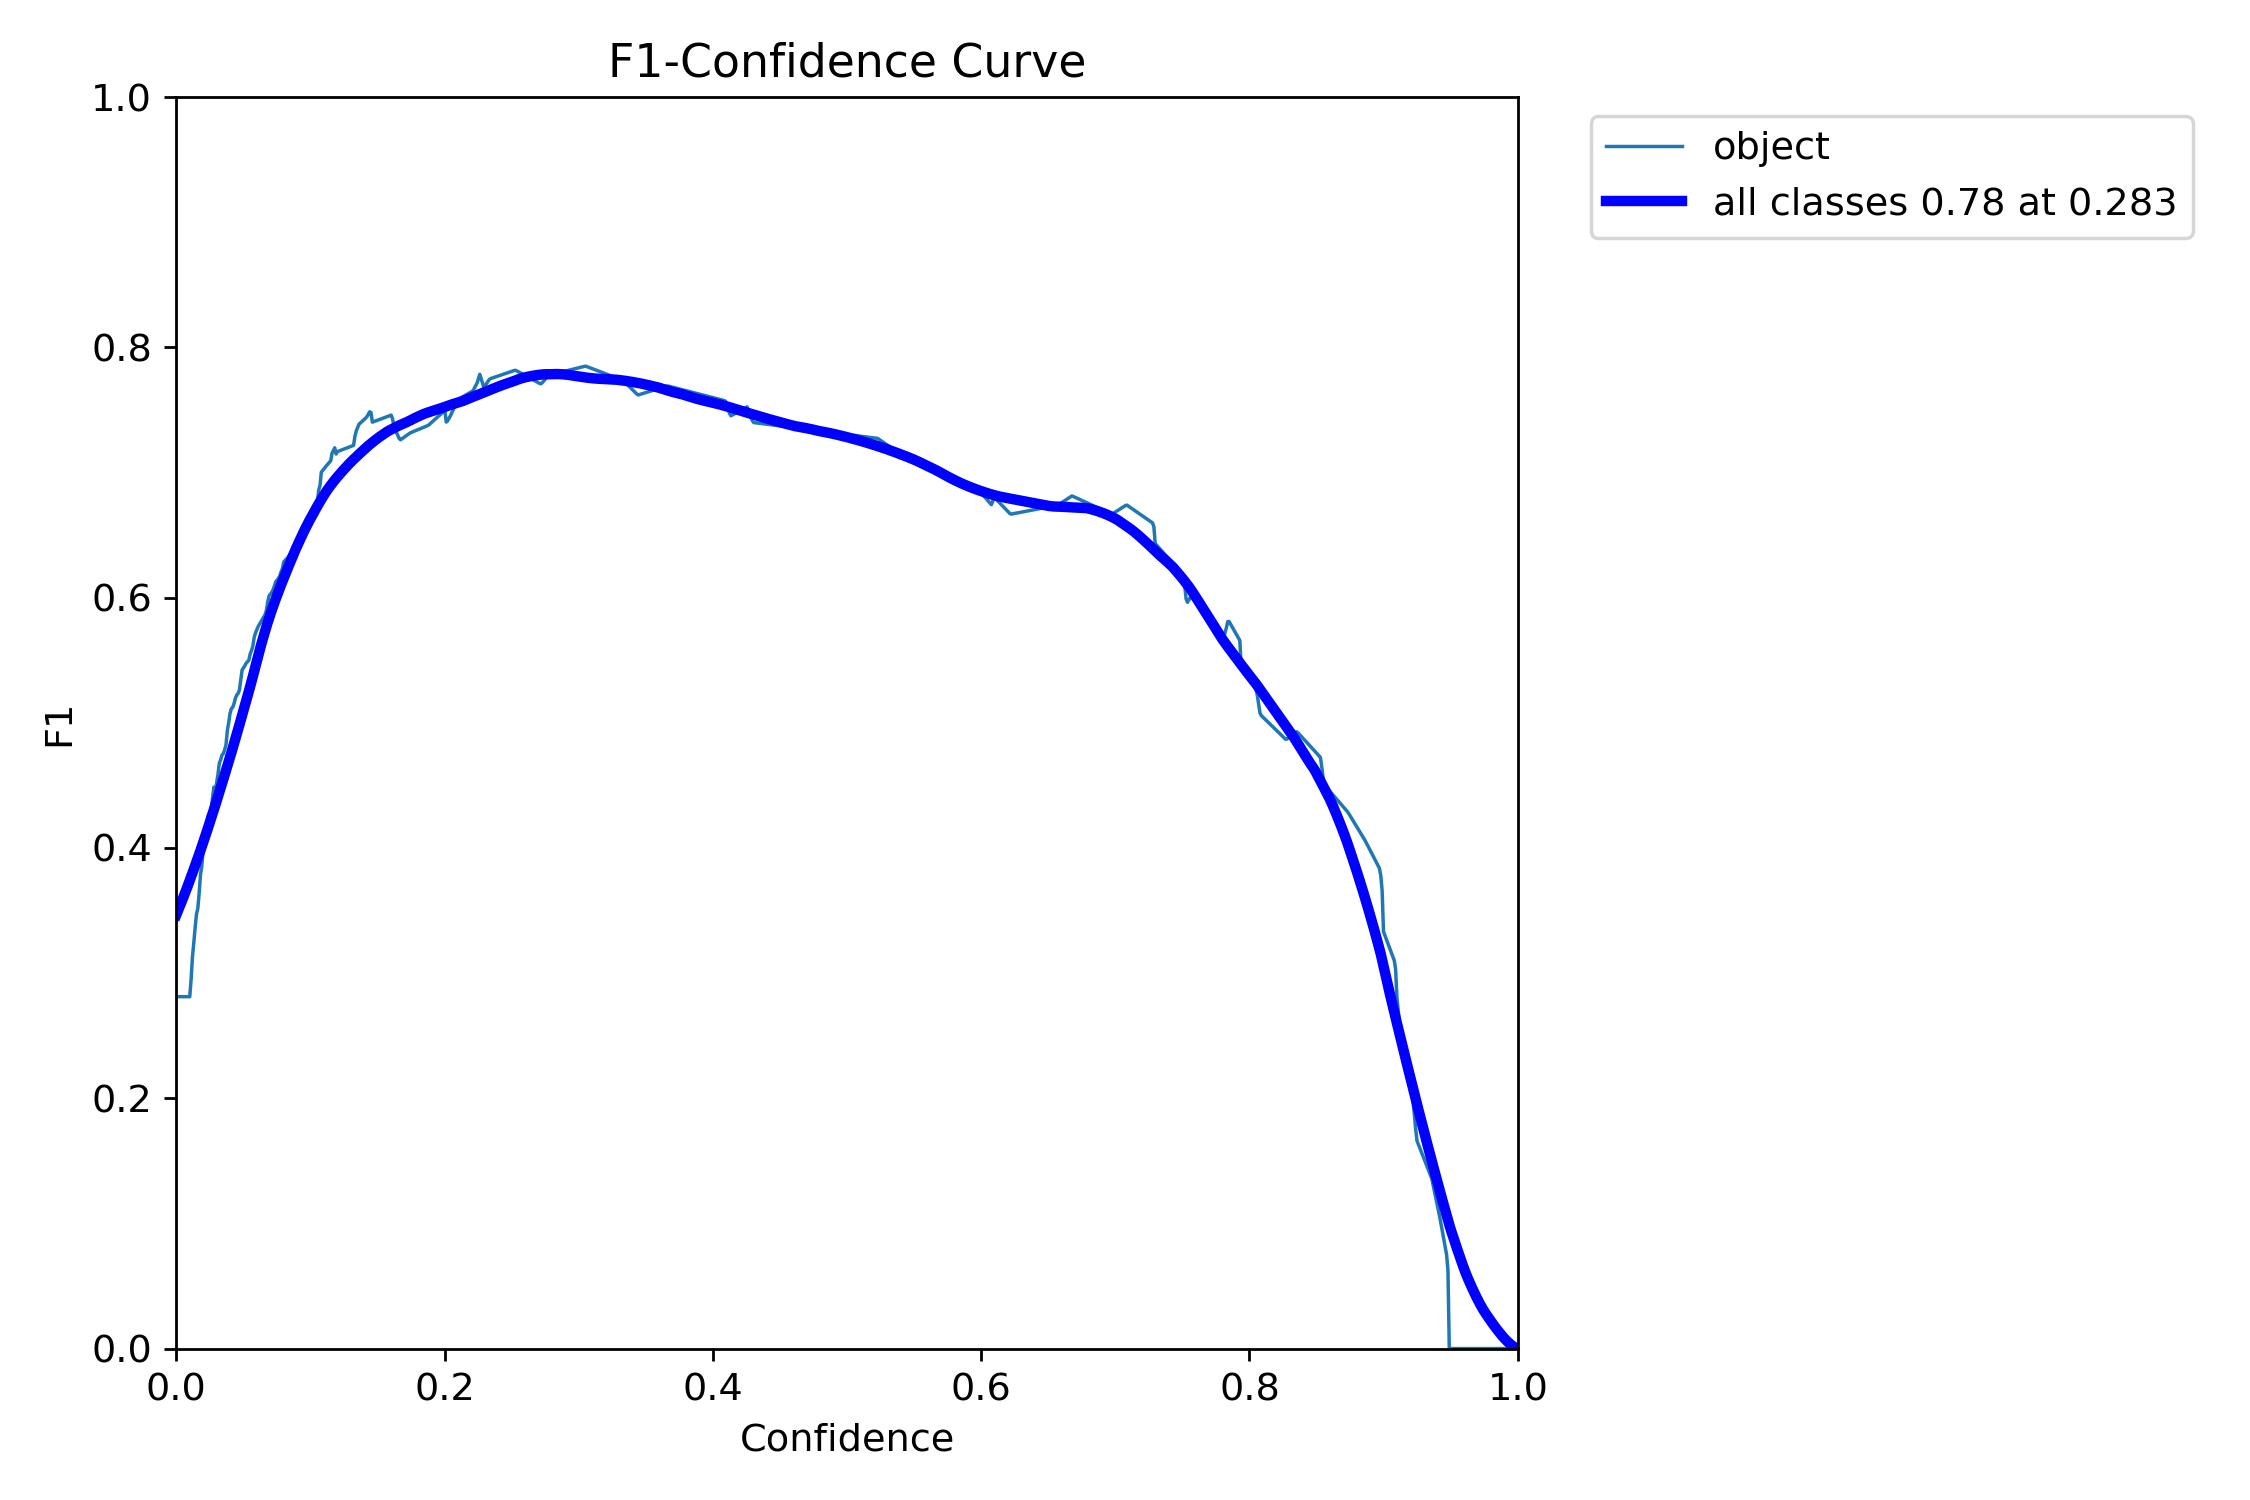

In [20]:
# Evaluation Curves
display(Image("/content/runs/obb/train/BoxPR_curve.png", width=600))
display(Image("/content/runs/obb/train/BoxP_curve.png", width=600))
display(Image("/content/runs/obb/train/BoxR_curve.png", width=600))
display(Image("/content/runs/obb/train/BoxF1_curve.png", width=600))

In [21]:
# Load the trained model
model = YOLO("/content/runs/obb/train/weights/best.pt")

# Run prediction
model.predict(
    source="/content/GE-healthcare-hackathon-1/test/images",
    save=True,
    conf=0.25
)


image 1/12 /content/GE-healthcare-hackathon-1/test/images/00000013_015_png.rf.7b1f701b2fdfc13ca722a7cbae652a9d.jpg: 640x640 2 objects, 203.5ms
image 2/12 /content/GE-healthcare-hackathon-1/test/images/00000013_034_png.rf.249ab1d40b2d1840b6652aaaf3c4e244.jpg: 640x640 2 objects, 201.5ms
image 3/12 /content/GE-healthcare-hackathon-1/test/images/00000038_003_png.rf.625047342dd87e2607a0637ee97cbf9e.jpg: 640x640 2 objects, 202.2ms
image 4/12 /content/GE-healthcare-hackathon-1/test/images/00000038_007_png.rf.372274b29b6fdbb17be5ab6e5be23f3d.jpg: 640x640 2 objects, 187.6ms
image 5/12 /content/GE-healthcare-hackathon-1/test/images/00000061_002_png.rf.b63ef1b24f4858bff24174677ef07664.jpg: 640x640 5 objects, 141.1ms
image 6/12 /content/GE-healthcare-hackathon-1/test/images/00000061_009_png.rf.5c4e5903591f897e4377879804269467.jpg: 640x640 4 objects, 144.3ms
image 7/12 /content/GE-healthcare-hackathon-1/test/images/00000061_016_png.rf.9f73f25332ac9daaab7ff158489e3666.jpg: 640x640 3 objects, 148.5m

[ultralytics.engine.results.Results object with attributes:
 
 boxes: None
 keypoints: None
 masks: None
 names: {0: 'object'}
 obb: ultralytics.engine.results.OBB object
 orig_img: array([[[ 61,  61,  61],
         [ 57,  57,  57],
         [ 52,  52,  52],
         ...,
         [144, 144, 144],
         [142, 142, 142],
         [141, 141, 141]],
 
        [[ 66,  66,  66],
         [ 63,  63,  63],
         [ 57,  57,  57],
         ...,
         [139, 139, 139],
         [139, 139, 139],
         [138, 138, 138]],
 
        [[ 74,  74,  74],
         [ 70,  70,  70],
         [ 64,  64,  64],
         ...,
         [140, 140, 140],
         [142, 142, 142],
         [142, 142, 142]],
 
        ...,
 
        [[ 18,  18,  18],
         [ 18,  18,  18],
         [ 29,  29,  29],
         ...,
         [116, 116, 116],
         [115, 115, 115],
         [115, 115, 115]],
 
        [[ 21,  21,  21],
         [ 22,  22,  22],
         [ 34,  34,  34],
         ...,
         [116, 116, 

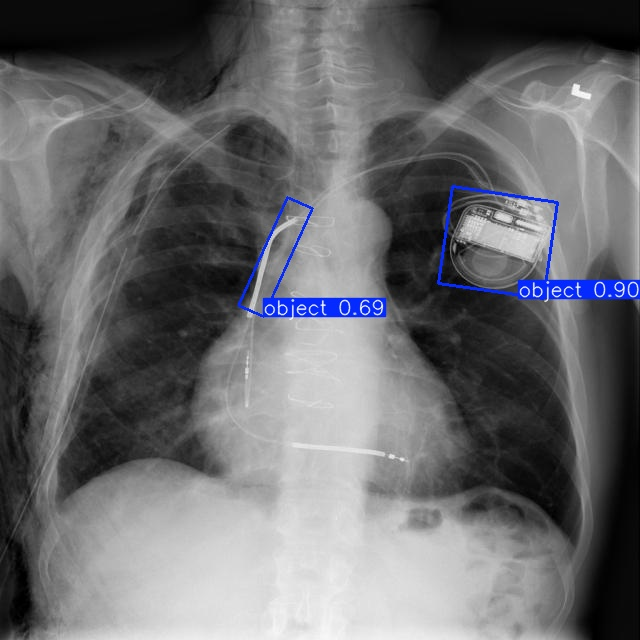

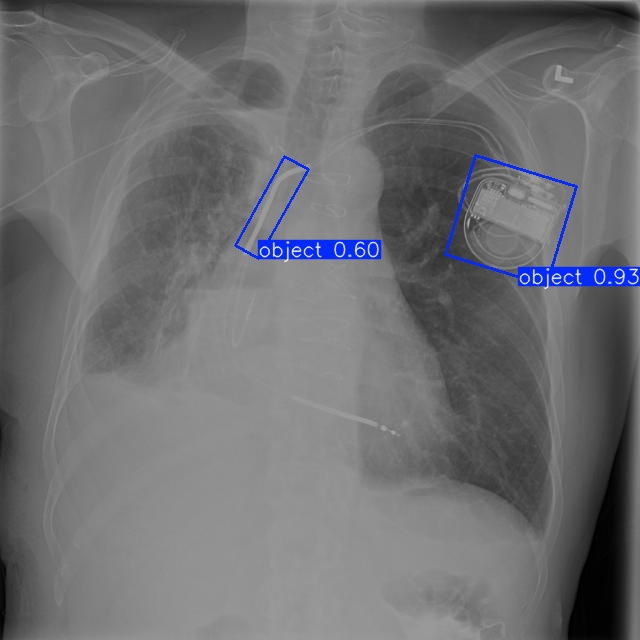

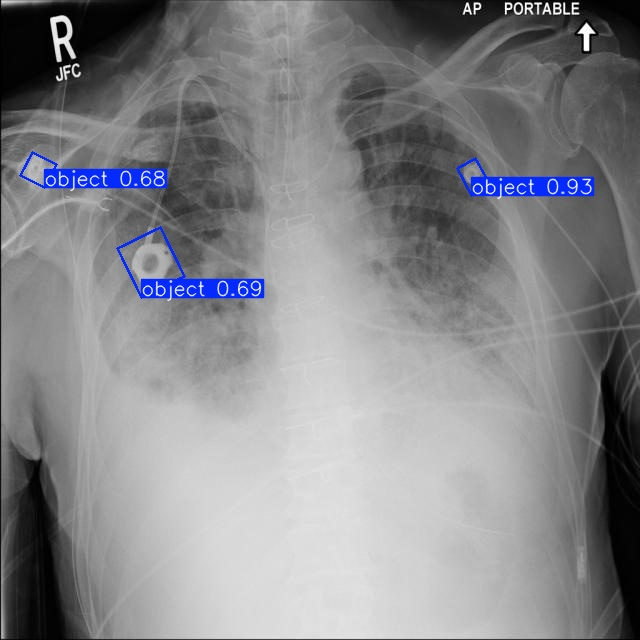

In [22]:
# Prediction Results
import glob
from IPython.display import Image, display

prediction_images = glob.glob("/content/runs/obb/predict/*")

for image in prediction_images[:3]:
    display(Image(image, width=700))

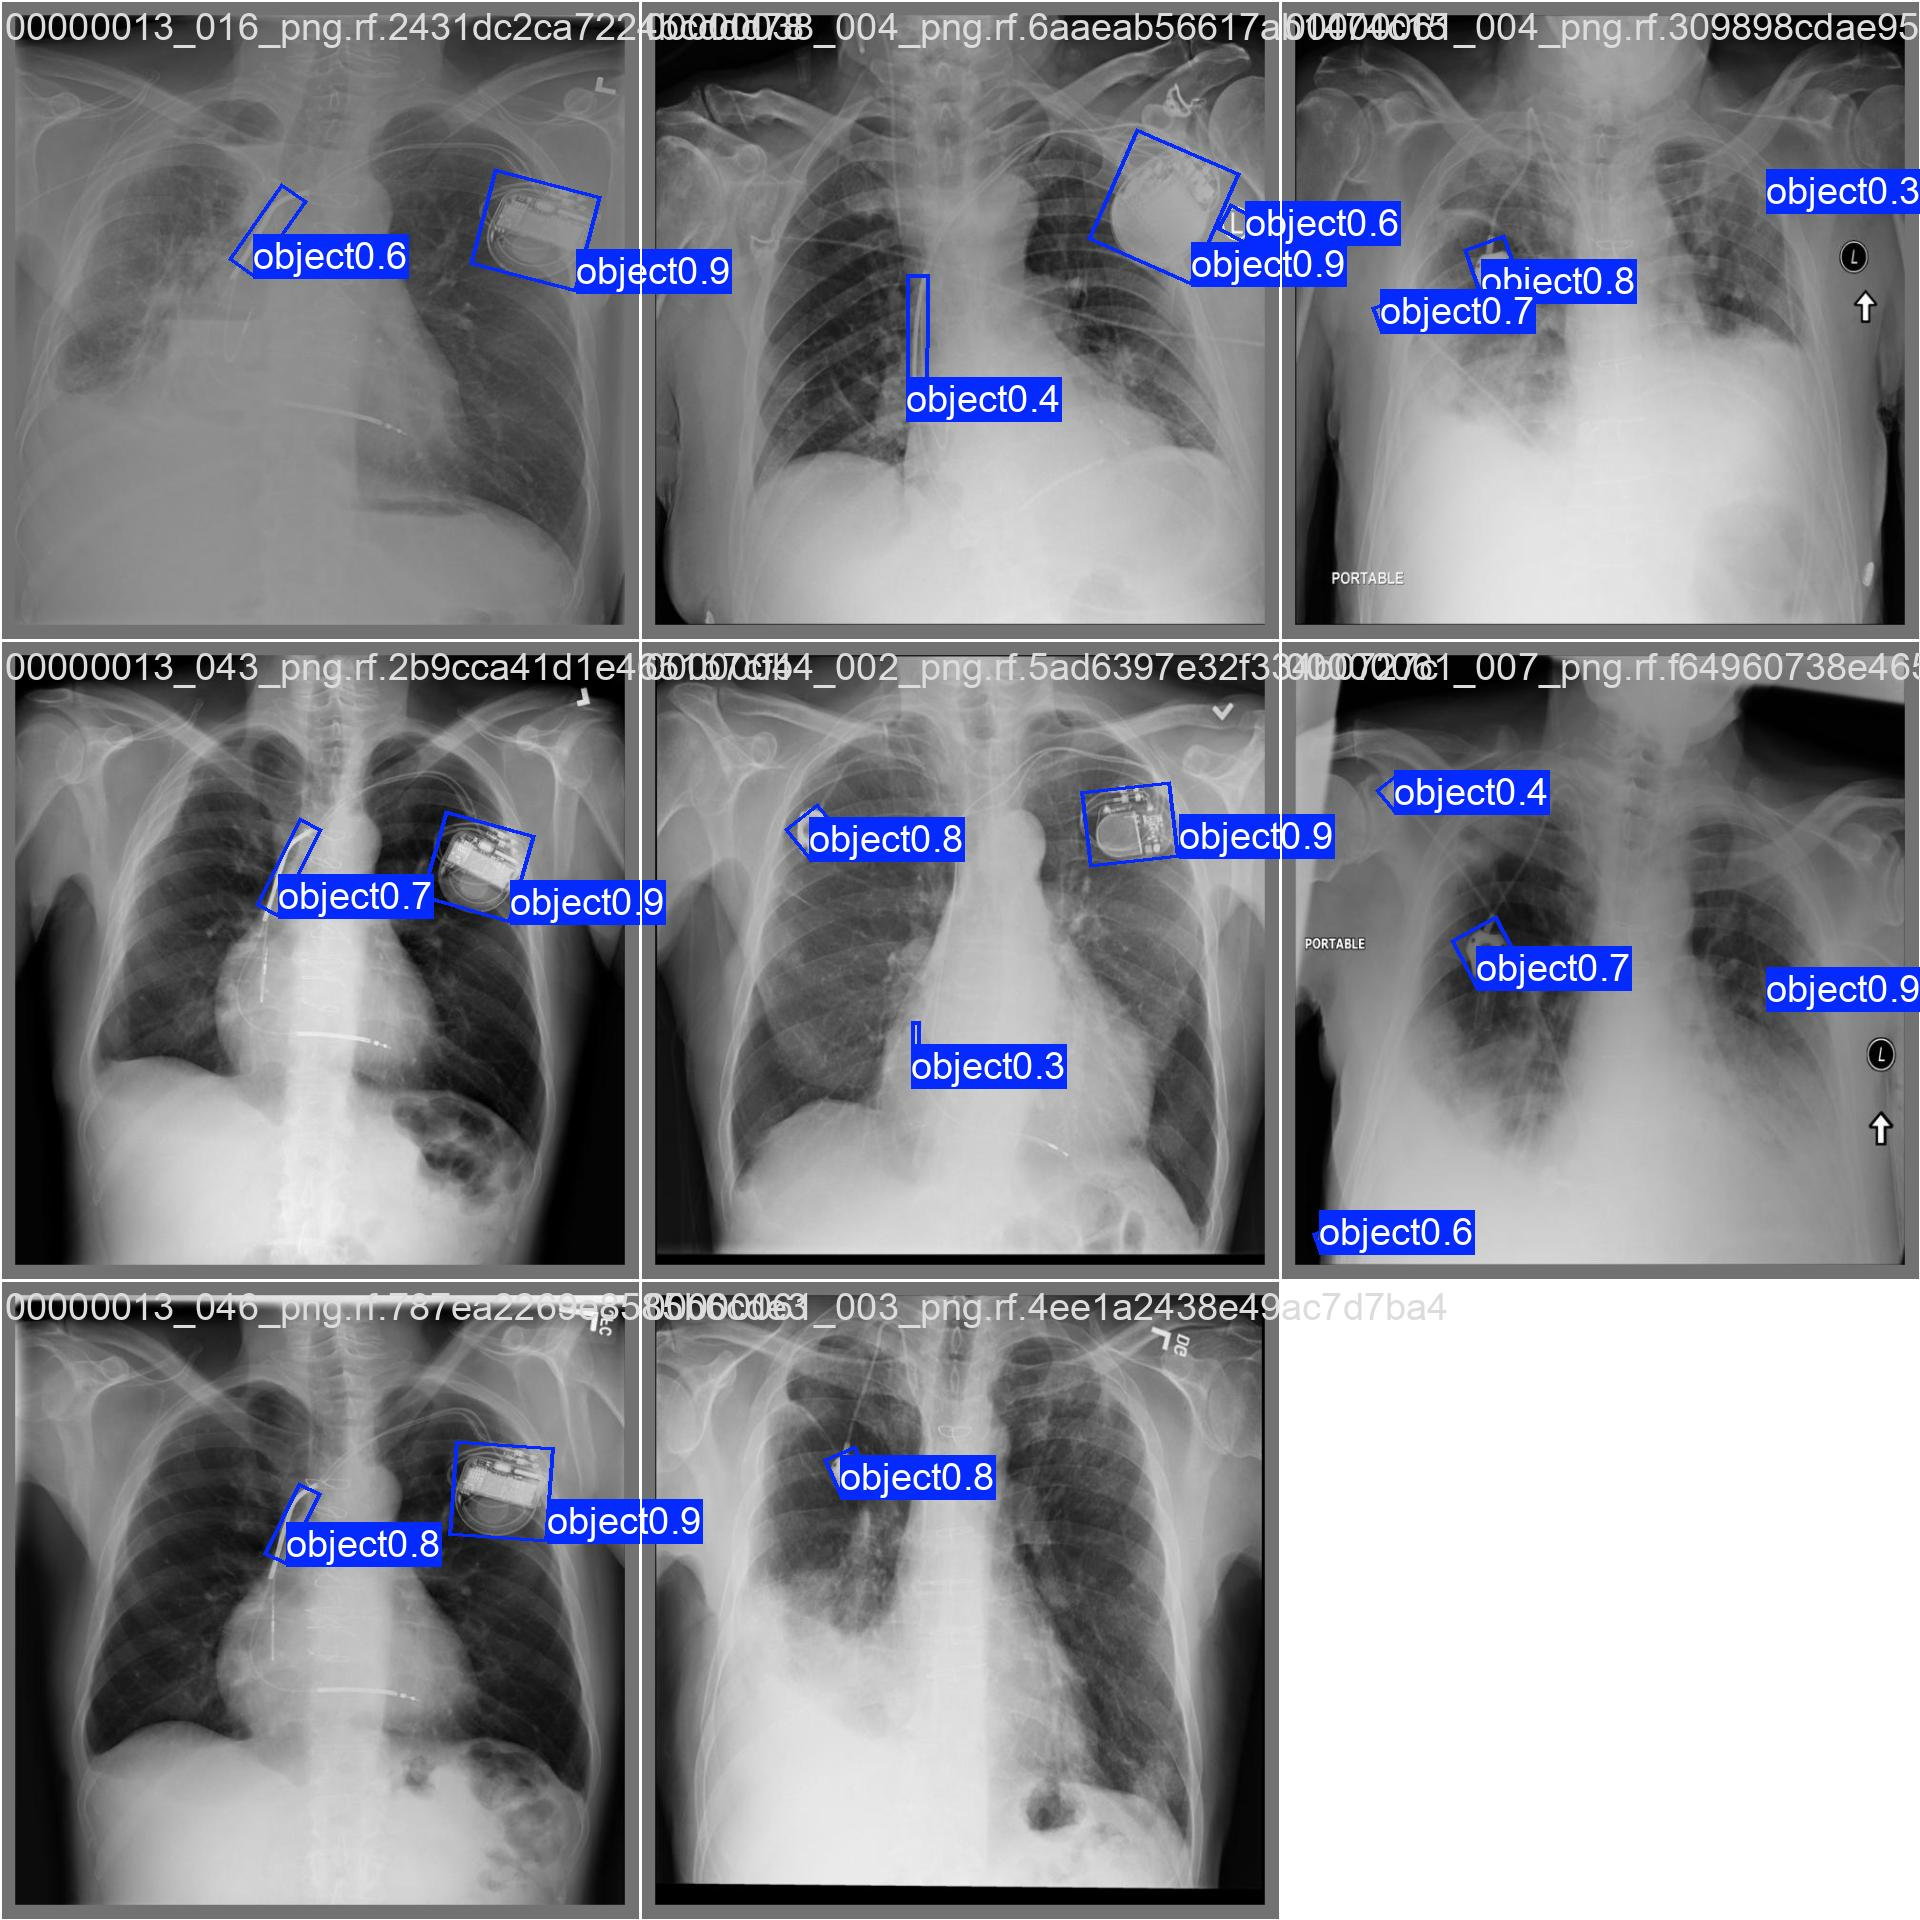

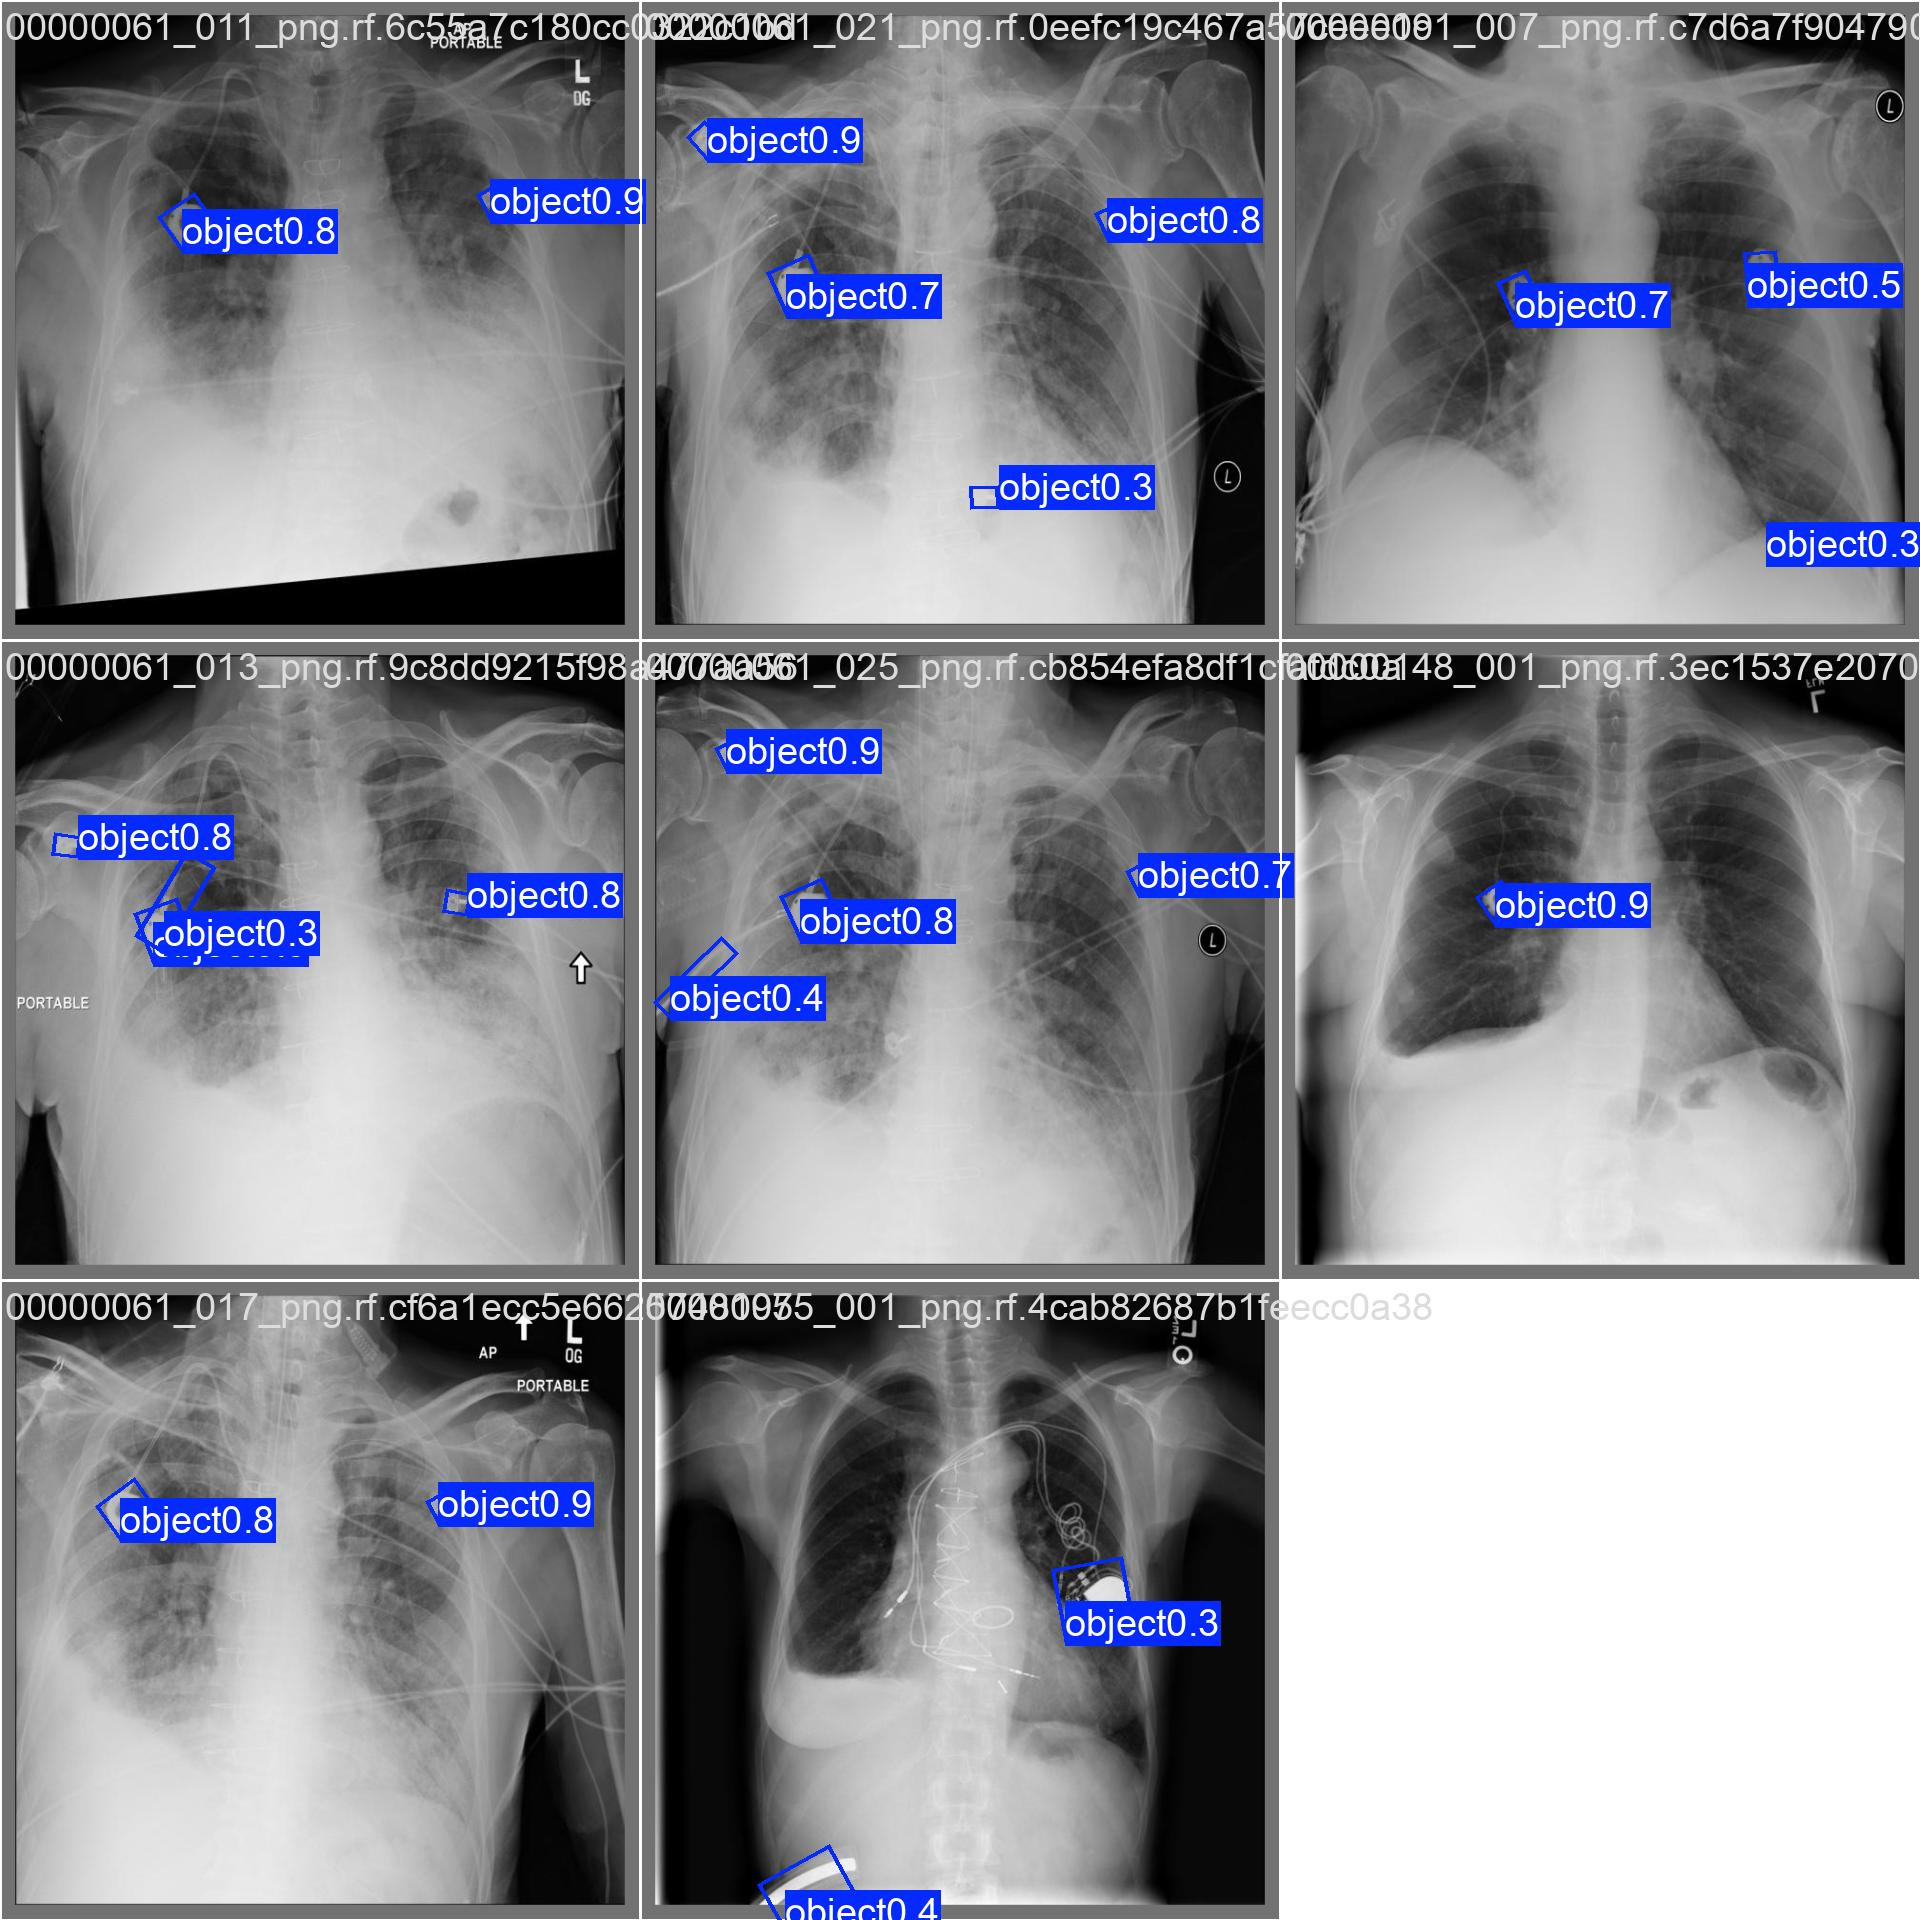

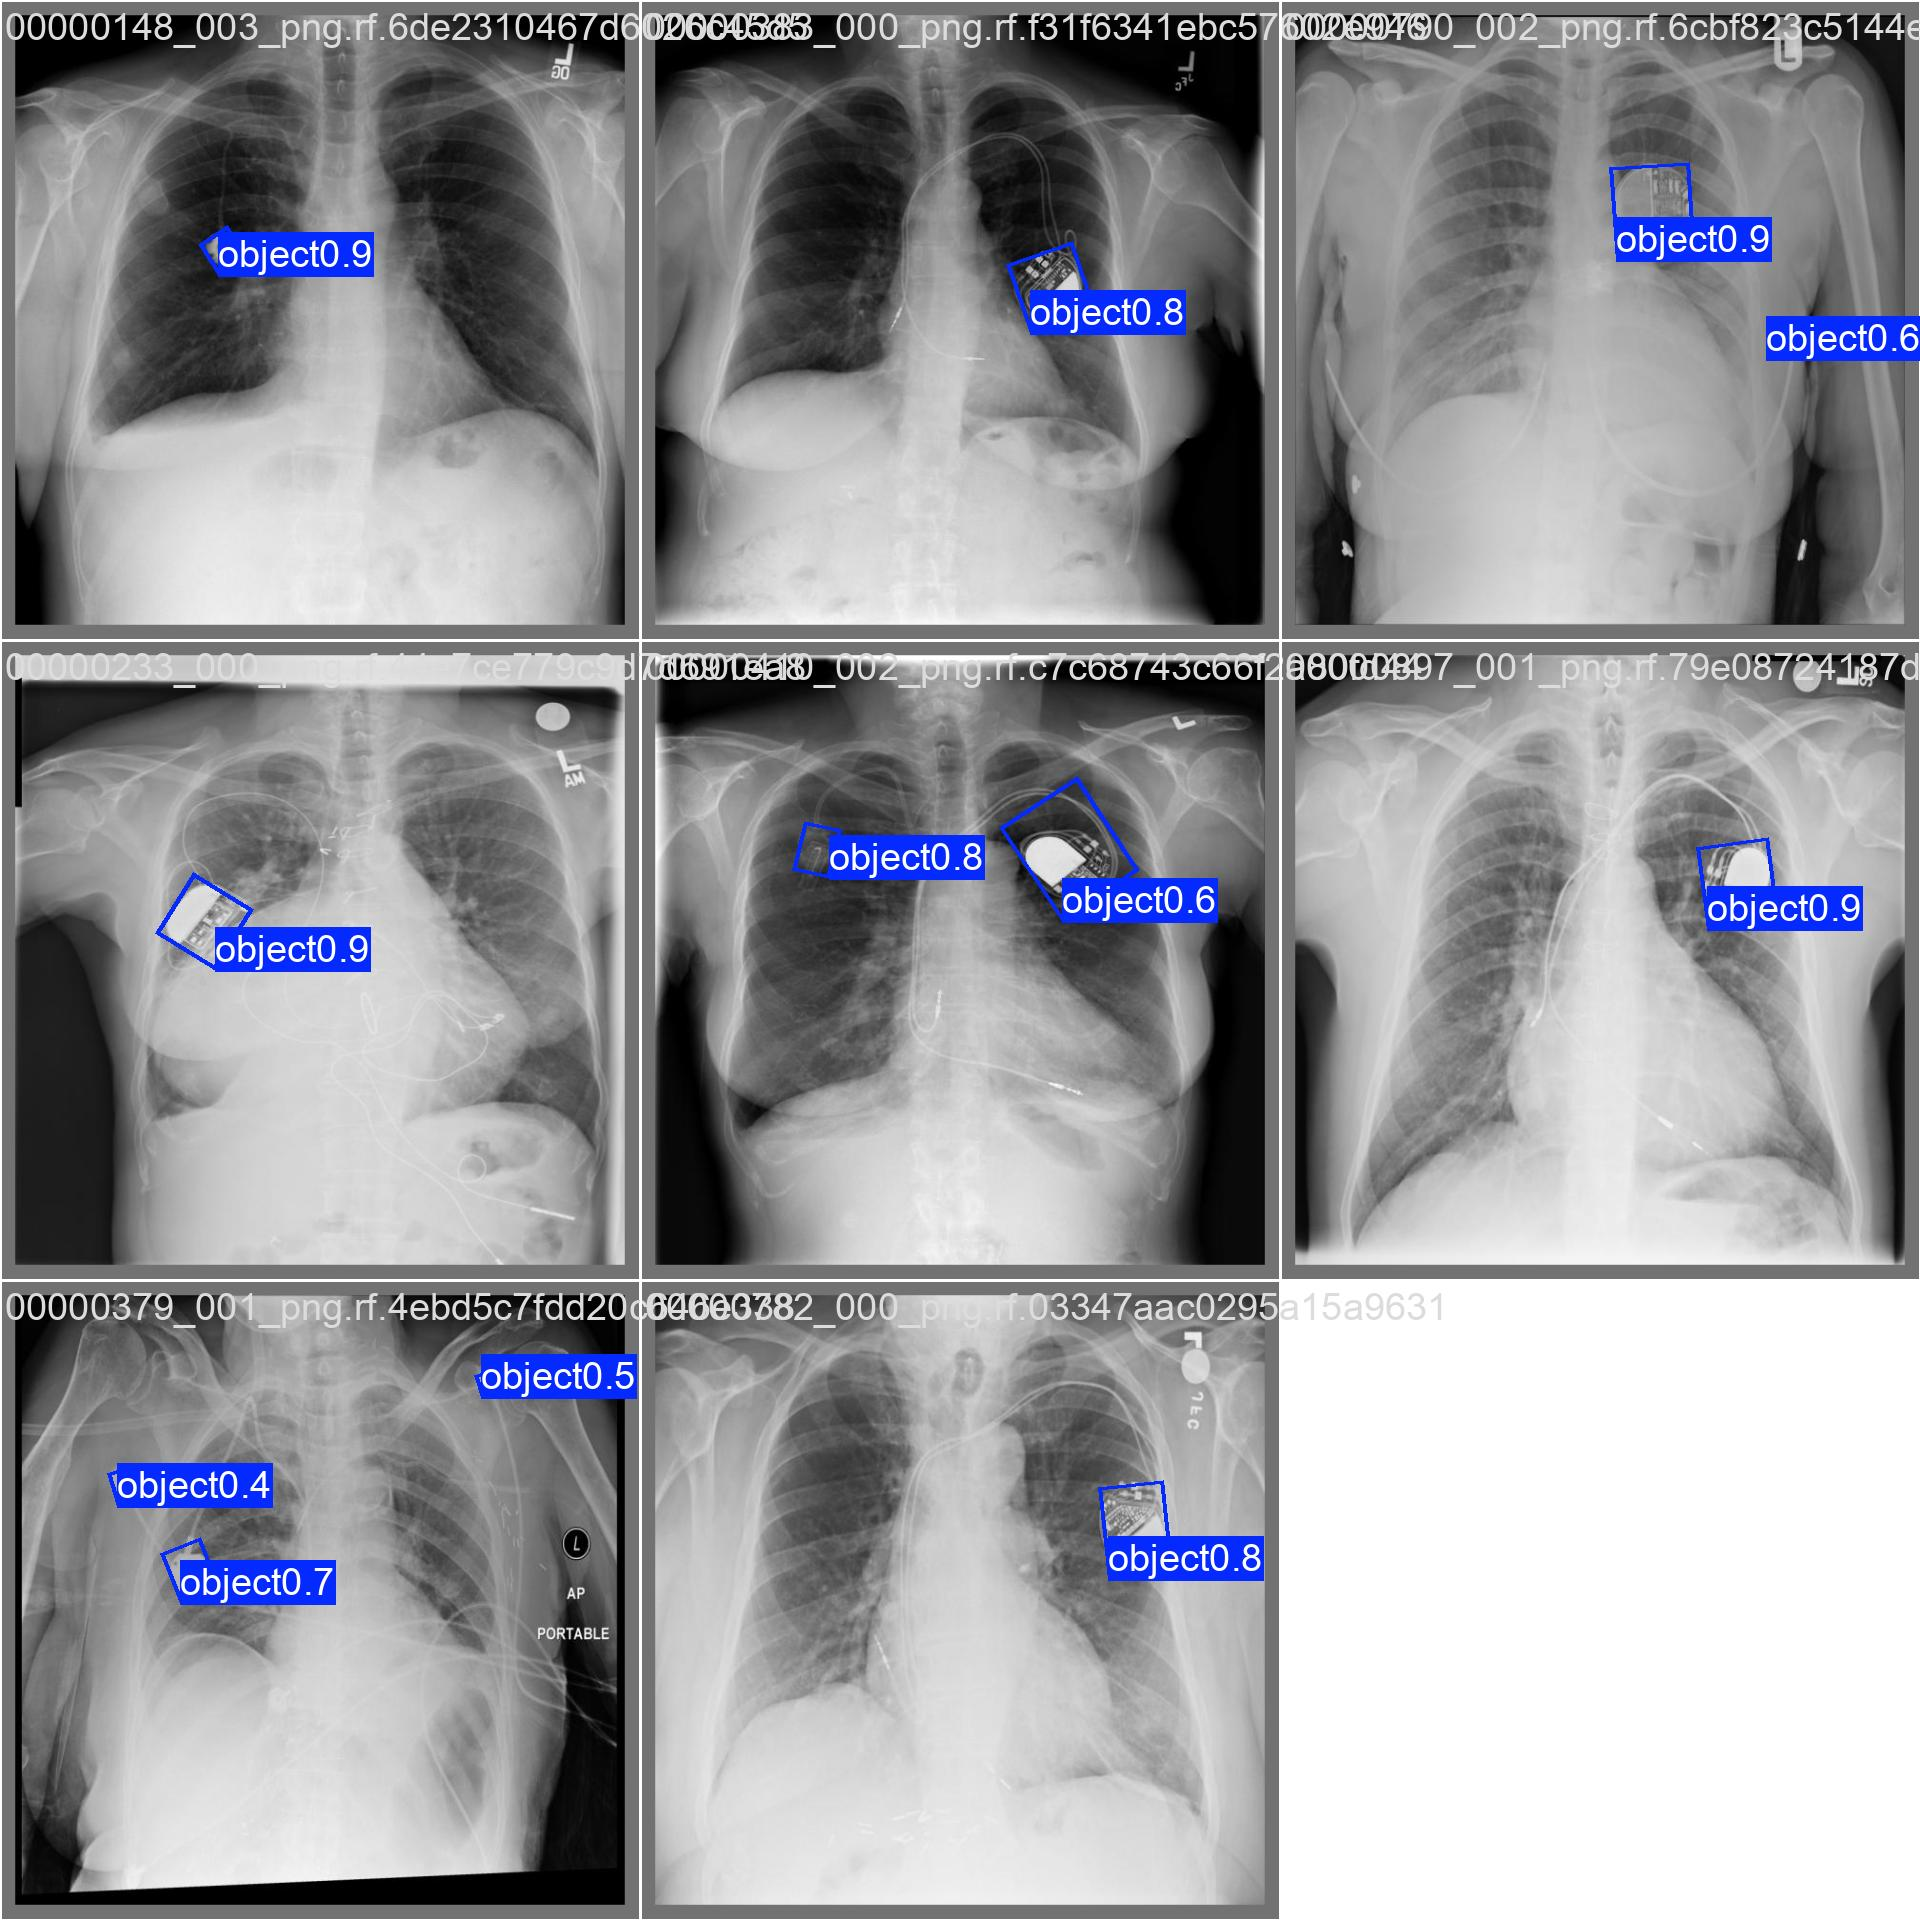

In [23]:
# Validation Images
display(Image("/content/runs/obb/train/val_batch0_pred.jpg", width=700))
display(Image("/content/runs/obb/train/val_batch1_pred.jpg", width=700))
display(Image("/content/runs/obb/train/val_batch2_pred.jpg", width=700))